*last updated: 23.03.26*

-----

## Notebook scope
- This notebook focuses on dataset understanding, cleaning decisions, and EDA.
- Polished storytelling visuals can be built later in Tableau.

----

# Notebook Summary

## What I found

### Year
- `Year` is not just a time variable; it also reflects major tournament-format changes.
- The 2020 and 2021 data should be treated as special pandemic-era years with a different competition structure.

### Round
- `Round` combines standard in-person bracket rounds with pandemic-era online double-elimination group-stage rounds.
- The 2020 and 2021 round structure is clearly different from the standard bracket years.

### Playstyle
- `Playstyle` shows a clear evolution over time:
  - `DAS` dominates the early years
  - `Tap` becomes dominant around 2020–2021
  - `Roll` appears in 2021 and dominates from 2022 onward

### Level / Start Level
- `Level` appears to represent start level.
- Start levels were not fully standardized in earlier years.
- From 2020 onward, all rows use level 18.

### Cap
- `Cap` is missing from 2010–2022 and starts being recorded in 2023.
- From 2023 onward, all rows use `39 KSx2`.
- **Working explanation of `39 KSx2`:** I currently treat this as a game/rules setup field, not a player performance metric. Based on the data, it behaves like a standardized competitive setting that starts being recorded from 2023 onward. I should confirm the exact official meaning with CTWC if I need to define it formally in the project.

### SPS
- `SPS` has no missing values.
- The pattern follows tournament structure:
  - 2010–2015: all `No`
  - standard bracket rounds from 2016 onward: mostly/all `Yes`
  - pandemic-era winners/losers rounds in 2020–2021: `No`

### Topout Type
- `Topout Type` mainly contains `Natural` and `Intentional`.
- `Aggressive` exists but is very rare.

### Final Score
- `Final Score` generally increases over time, especially in recent years.
- The year trend is strongly affected by round coverage, tournament format, and playstyle.
- `Tap` generally scores above `DAS`, and `Roll` generally scores above `Tap`.
- There are 3 rows with `Final Score = 0`.

### Total Lines
- `Total Lines` generally increases over time, especially in recent years.
- The pattern is broadly similar to `Final Score`, but less dramatic.
- The highest `Total Lines` outliers are very extreme and are all associated with `Roll`.
- `Total Lines` has 18 missing values.

### Final Score × Total Lines
- `Final Score` and `Total Lines` are very strongly related (correlation ≈ 0.94).
- At similar line counts, newer playstyles tend to achieve higher scores.
- This suggests a possible scoring-efficiency difference, but not a proven causal effect.

---

## Complete summary of missing values (and thoughts)

### Total Lines
- `Total Lines` has **18 missing values**.
- Missing rows appear in:
  - **2014:** Game IDs `115`, `117`, `119`
  - **2016:** Game IDs `256`, `258`, `264`, `266`, `271`, `273`, `276`, `278`, `280`
  - **2021:** Game ID `1813`
  - **2022:** Game ID `2385`
  - **2025:** Game IDs `3993`, `3994`, `4003`, `4004`
- **What I could prove:** the missing values are real `NaN` values, not formatting issues. They are spread across multiple years, not concentrated in one single block only.
- **What I think:** this looks like a small source-data completeness issue rather than a structural missingness pattern like the transition columns. The amount is small enough to keep the column usable, so I will leave these values as `NaN`. If needed later, I can check footage for these specific game IDs.

### Topout Type
- `Topout Type` has **1 missing value**.
- Missing row:
  - **2024, Top 32:** Match ID `531`, Game ID `3635`, player `Fractal`
- **What I could prove:** this is a true missing value, not a general pattern in the column.
- **What I think:** this is a tiny isolated source-data issue and does not affect the usefulness of the column. I will keep it as `NaN`.

### Cap
- `Cap` is missing for all rows from **2010 to 2022**.
- **What I could prove:** once `Cap` starts appearing in **2023**, it is recorded consistently and always shown as `39 KSx2`.
- **What I think:** this is not random row-level missingness. It looks like a field that was only introduced or only recorded from 2023 onward.

### No M Score
- `No M Score` contains many missing values.
- **What I could prove:** missingness is common, especially in rows where `Won? = No`, but the pattern is not fully consistent. I also found rows where `No M Score` exists while `No M Lines` is missing.
- **What I think:** I do not understand this column well enough yet to treat the missingness as normal or abnormal. I should not use it as a main analysis column until CTWC clarifies it.

### No M Lines
- `No M Lines` contains many missing values.
- **What I could prove:** its missingness pattern partly overlaps with `No M Score`, but not perfectly. There are inconsistent cases, including rows where `No M Score` exists while `No M Lines` is missing.
- **What I think:** like `No M Score`, this column is not yet safe to interpret. I need CTWC clarification before using it seriously.

### Transition columns
- `19 Trans`, `19 L Start`, `29 Trans`, `29 L Start`, `39 Trans`, and `39 L Start` all contain many missing values.
- **What I could prove:** these missing values follow a structural pattern. If a player did not reach a milestone, the related values are expected to be `NaN`.
- **What I think:** this is expected structural missingness, not a data-quality problem. I should keep these `NaN` values as they are.

### Final Score
- `Final Score` has **no missing values**, but it contains **3 rows with value `0`**.
- These occur in:
  - **2020 | WQ**
  - **2021 | WQ**
  - **2022 | Top 16**
- **What I could prove:** these are recorded values, not missing values. All 3 are losses with `Topout Type = Natural`.
- **What I think:** these zero values are suspicious and should be checked later, especially the 2022 `Top 16` case.

### Total Lines = 0
- `Total Lines` also contains rows with value `0`.
- **What I could prove:** these are recorded values, not missing values.
- **What I think:** they should be treated separately from true missing values. Some may be legitimate edge cases, while others may need checking if they become important to the analysis.

### SPS
- `SPS` has **no missing values**.
- **What I could prove:** the column is complete, and its pattern is driven by year and tournament structure.
- **What I think:** no missing-value concern here.

### Playstyle
- `Playstyle` has **no missing values**.
- **What I could prove:** the column is complete and highly informative over time.
- **What I think:** no missing-value concern here.

### Level
- `Level` has **no missing values**.
- **What I could prove:** the column is complete.
- **What I think:** no missing-value concern here.

### Year
- `Year` has **no missing values**.
- **What I could prove:** the column is complete.
- **What I think:** no missing-value concern here.

### Round
- `Round` has **no missing values**.
- **What I could prove:** the column is complete, but the meanings of some labels still need confirmation.
- **What I think:** this is a meaning/definition issue, not a missing-value issue.

### Post / Post Post
- I did not confirm missingness patterns for `Post` and `Post Post` in the notebook analysis so far.
- **What I could prove:** not enough yet.
- **What I think:** these columns still need separate review for both meaning and missingness if they become relevant later.

---

## Still to do

### Columns / naming
- Rename columns to lowercase with underscores and no spaces.
- Rename `Level` to `Start Level` in the working dataframe.
- Rename the pandemic-era `Round` values into readable full names in the working dataframe while keeping the raw values documented.

### Round
- Replace abbreviations with readable labels in the working version:
  - `WQ`
  - `WS`
  - `WF`
  - `LQ`
  - `LS`
  - `LF`
  - `GF`
  - `GFBR`
  - `L T8`

### Notebook / project
- Decide which notebook findings should become Tableau visuals.
- Turn the strongest EDA findings into a short analysis/story structure.

---

## Need CTWC confirmation

### Round
- Confirm the exact official meaning of:
  - `GFBR`
  - `L T8`
- Confirm whether the working expansions for the other 2020–2021 round abbreviations are officially correct.

### No M Score / No M Lines
- Confirm the exact meaning of `No M Score`.
- Confirm the exact meaning of `No M Lines`.
- Confirm how these columns should be interpreted when one is present and the other is missing.

### Post / Post Post
- Confirm the meaning of `Post`.
- Confirm the meaning of `Post Post`.
- Confirm whether these are statistics, position indicators, or something else.

### Topout Type
- Confirm the official meaning of `Aggressive`.

### SPS
- Confirm the rule/background explanation behind the `SPS` pattern, if needed.

---

## Need further investigation

### Total Lines
- Check footage for the 18 missing `Total Lines` rows.  
  Game IDs:
  - 115
  - 117
  - 119
  - 256
  - 258
  - 264
  - 266
  - 271
  - 273
  - 276
  - 278
  - 280
  - 1813
  - 2385
  - 3993
  - 3994
  - 4003
  - 4004

### Topout Type
- Check footage for the 1 missing `Topout Type` row.  
  Game ID:
  - 3635

### Final Score
- Check the 3 rows with `Final Score = 0`, especially the 2022 `Top 16` case.

### Total Lines
- Check the rows with `Total Lines = 0`.
- Revisit the very low-line outliers and extreme high-line outliers later if they become relevant to the story.

### Year / score interpretation
- Keep in mind that some early-year distributions are unstable because of very small row counts, especially 2010.

---

## Good Tableau candidates

### Structure over time
- `Year × Round`
- pandemic-era round structure vs standard years
- `Year × SPS`

### Playstyle evolution
- `Year × Playstyle`

### Performance over time
- median `Final Score` by year
- median `Total Lines` by year

### Performance by playstyle
- `Final Score × Year × Playstyle`
- `Total Lines × Year × Playstyle`

### Score vs survival
- `Final Score × Total Lines`
- colored by `Playstyle`

### Outliers
- highest `Final Score`
- highest `Total Lines`
- low `Total Lines` by year and round

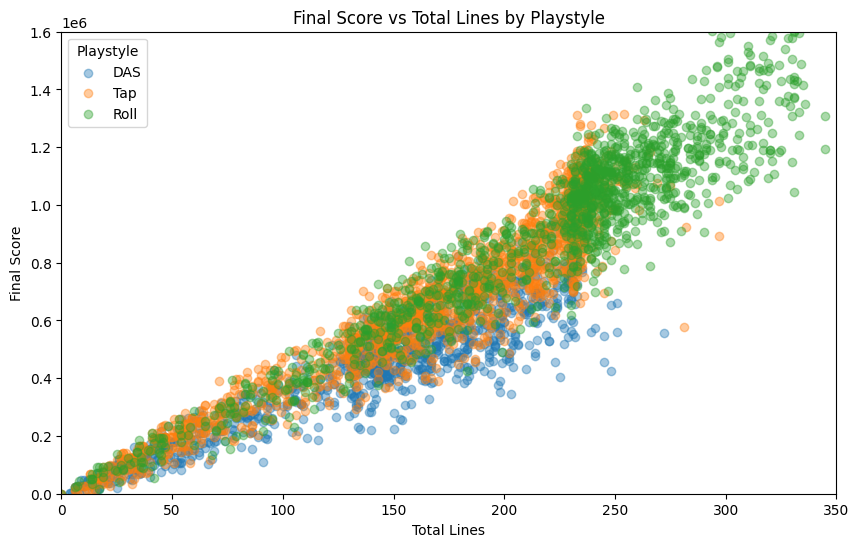

In [180]:
playstyle_order = ["DAS", "Tap", "Roll"]

plt.figure(figsize=(10, 6))

for playstyle in playstyle_order:
    subset = df[df["Playstyle"] == playstyle]
    plt.scatter(
        subset["Total Lines"],
        subset["Final Score"],
        alpha=0.4,
        label=playstyle
    )

plt.title("Final Score vs Total Lines by Playstyle")
plt.xlabel("Total Lines")
plt.ylabel("Final Score")
plt.xlim(0, 350)
plt.ylim(0, 1600000)
plt.legend(title="Playstyle")
plt.show()

________________________________________________________________________________________________
________________________________________________________________________________________________

# Data Exploration

________________________________________________________________________________________________
________________________________________________________________________________________________

In [88]:
import sys
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt


print(sys.executable)
print(pd.__version__)
print(np.__version__)
print(sklearn.__version__)

/Users/sanaaarsman/dev/ironhack/projects/CTWC/.venv/bin/python
3.0.1
2.4.3
1.8.0


In [5]:
file_path = "../data/raw_data/public_ctwc_match_statistics.xlsx"

excel_file = pd.ExcelFile(file_path)

for sheet in excel_file.sheet_names:
    print(sheet)

All Time Leaderboards
Yearly Leaderboards
Custom Leaderboard
Player Statistics
Player Profiles
Player History
Box Scores
Head to Head
MARFRAM STATS
Year Stats
All Games
Validation
Player Info
Countries
All Time Leaderboard Stats
Yearly Leaderboard Stats
Custom Leaderboard Stats
Player Statistics Games


In [6]:
df_all_games = pd.read_excel(file_path, sheet_name="All Games")
df_all_games.head()

,Player,Game,Playstyle,Won?,Final Score,Total Lines,No M Score,No M Lines,19 Trans,19 L Start,...,Cap,SPS,Year,Unnamed: 19,Round,Game Link,Game ID,Match ID,Post,Post Post
0,Jonas,1,DAS,Yes,530034,195.0,339042.0,135.0,522034.0,190.0,...,NaN,No,2010,NaN,Finals,https://youtu.be/ZL4eRDOOP1I?t=24,1,1,NaN,NaN
1,Harry Hong,1,DAS,No,302118,133.0,NaN,NaN,NaN,NaN,...,NaN,No,2010,NaN,Finals,https://youtu.be/ZL4eRDOOP1I?t=24,2,1,NaN,NaN
2,Jonas,2,DAS,Yes,544534,245.0,542531.0,243.0,443999.0,192.0,...,NaN,No,2010,NaN,Finals,https://youtu.be/ZL4eRDOOP1I?t=595,3,1,NaN,NaN
3,Harry Hong,2,DAS,No,517590,227.0,NaN,NaN,483111.0,191.0,...,NaN,No,2010,NaN,Finals,https://youtu.be/ZL4eRDOOP1I?t=595,4,1,NaN,NaN
4,Jonas,1,DAS,Yes,164153,55.0,164153.0,55.0,NaN,NaN,...,NaN,No,2011,NaN,Top 8,https://youtu.be/8sorxlk7QLs?t=14,5,2,NaN,NaN


In [7]:
pd.set_option("display.max_columns", None)
df_all_games.head()

,Player,Game,Playstyle,Won?,Final Score,Total Lines,No M Score,No M Lines,19 Trans,19 L Start,29 Trans,29 L Start,39 Trans,39 L Start,Topout Type,Level,Cap,SPS,Year,Unnamed: 19,Round,Game Link,Game ID,Match ID,Post,Post Post
0,Jonas,1,DAS,Yes,530034,195.0,339042.0,135.0,522034.0,190.0,NaN,NaN,NaN,NaN,Natural,9,NaN,No,2010,NaN,Finals,https://youtu.be/ZL4eRDOOP1I?t=24,1,1,NaN,NaN
1,Harry Hong,1,DAS,No,302118,133.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,9,NaN,No,2010,NaN,Finals,https://youtu.be/ZL4eRDOOP1I?t=24,2,1,NaN,NaN
2,Jonas,2,DAS,Yes,544534,245.0,542531.0,243.0,443999.0,192.0,NaN,NaN,NaN,NaN,Intentional,9,NaN,No,2010,NaN,Finals,https://youtu.be/ZL4eRDOOP1I?t=595,3,1,NaN,NaN
3,Harry Hong,2,DAS,No,517590,227.0,NaN,NaN,483111.0,191.0,NaN,NaN,NaN,NaN,Natural,9,NaN,No,2010,NaN,Finals,https://youtu.be/ZL4eRDOOP1I?t=595,4,1,NaN,NaN
4,Jonas,1,DAS,Yes,164153,55.0,164153.0,55.0,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,No,2011,NaN,Top 8,https://youtu.be/8sorxlk7QLs?t=14,5,2,NaN,NaN


In [ ]:
# Small cleanup for readabillity
df = df_all_games.copy()

In [9]:
df = df.drop(columns=["Unnamed: 19", "Game Link"])


In [10]:
front_cols = ["Year", "Round", "Match ID", "Game ID", "Game", "Player", "Won?"]
other_cols = [col for col in df.columns if col not in front_cols]
df = df[front_cols + other_cols]

df.head()


,Year,Round,Match ID,Game ID,Game,Player,Won?,Playstyle,Final Score,Total Lines,No M Score,No M Lines,19 Trans,19 L Start,29 Trans,29 L Start,39 Trans,39 L Start,Topout Type,Level,Cap,SPS,Post,Post Post
0,2010,Finals,1,1,1,Jonas,Yes,DAS,530034,195.0,339042.0,135.0,522034.0,190.0,NaN,NaN,NaN,NaN,Natural,9,NaN,No,NaN,NaN
1,2010,Finals,1,2,1,Harry Hong,No,DAS,302118,133.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,9,NaN,No,NaN,NaN
2,2010,Finals,1,3,2,Jonas,Yes,DAS,544534,245.0,542531.0,243.0,443999.0,192.0,NaN,NaN,NaN,NaN,Intentional,9,NaN,No,NaN,NaN
3,2010,Finals,1,4,2,Harry Hong,No,DAS,517590,227.0,NaN,NaN,483111.0,191.0,NaN,NaN,NaN,NaN,Natural,9,NaN,No,NaN,NaN
4,2011,Top 8,2,5,1,Jonas,Yes,DAS,164153,55.0,164153.0,55.0,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,No,NaN,NaN


In [12]:
print("Shape:", df.shape)

Shape: (4202, 24)


In [13]:
print("\nData types:")
print(df.dtypes)


Data types:
Year             int64
Round              str
Match ID         int64
Game ID          int64
Game             int64
Player             str
Won?               str
Playstyle          str
Final Score      int64
Total Lines    float64
No M Score     float64
No M Lines     float64
19 Trans       float64
19 L Start     float64
29 Trans       float64
29 L Start     float64
39 Trans       float64
39 L Start     float64
Topout Type        str
Level            int64
Cap                str
SPS                str
Post           float64
Post Post      float64
dtype: object


In [14]:
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
Year              0
Round             0
Match ID          0
Game ID           0
Game              0
Player            0
Won?              0
Playstyle         0
Final Score       0
Total Lines      18
No M Score     2129
No M Lines     2134
19 Trans        919
19 L Start      921
29 Trans       2957
29 L Start     2957
39 Trans       4170
39 L Start     4170
Topout Type       1
Level             0
Cap            3138
SPS               0
Post            990
Post Post      2963
dtype: int64


Interesting things: 
- total lines 18
- topout type 1 

Things i can not judge yet because of the lack of understanding:
- post
- post post 
- No M Score 2129
- No M Lines 2134

Columns that are fine to have Nulls. Players just didn't reach that stage.
- 19 Trans 919
- 19 L Start 921
- 29 Trans 2957
- 29 L Start 2957
- 39 Trans 4170
- 39 L Start 4170
- Cap 3138

In [15]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [16]:
df[df["Total Lines"].isna()]

,Year,Round,Match ID,Game ID,Game,Player,Won?,Playstyle,Final Score,Total Lines,No M Score,No M Lines,19 Trans,19 L Start,29 Trans,29 L Start,39 Trans,39 L Start,Topout Type,Level,Cap,SPS,Post,Post Post
114,2014,Top 16,24,115,1,Cameron Eure,Yes,DAS,642660,NaN,642660.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
116,2014,Top 16,24,117,2,Cameron Eure,No,DAS,140600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
118,2014,Top 16,24,119,3,Cameron Eure,No,DAS,468540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
255,2016,Top 32,52,256,1,Adam Cornelius,No,DAS,51680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,NaN,NaN
257,2016,Top 32,52,258,2,Adam Cornelius,No,DAS,298780,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,15,NaN,Yes,NaN,NaN
263,2016,Top 32,54,264,1,Vince,No,DAS,277630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,15,NaN,Yes,NaN,NaN
265,2016,Top 32,54,266,2,Vince,No,DAS,82840,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,NaN,NaN
270,2016,Top 32,56,271,1,Chris Brady,No,DAS,428371,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,NaN,NaN
272,2016,Top 32,56,273,2,Chris Brady,No,DAS,35878,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,NaN,NaN
275,2016,Top 32,57,276,1,TheMetalBeast,No,DAS,265732,NaN,NaN,NaN,265732.0,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,NaN,NaN


In [ ]:
# No clear answer to why the "Total Lines" columns has NaN's 

In [17]:
df[df["Total Lines"].isna()]["Year"].value_counts().sort_index()

Year
2014    3
2016    9
2021    2
2025    4
Name: count, dtype: int64

In [18]:
df[df["Total Lines"].isna()]["Round"].value_counts()

Round
Top 32    13
Top 16     3
WQ         2
Name: count, dtype: int64

In [19]:
df[df["Total Lines"].isna()]["Playstyle"].value_counts()

Playstyle
DAS     12
Roll     4
Tap      2
Name: count, dtype: int64

In [20]:
df[df["Total Lines"].isna()]["SPS"].value_counts()

SPS
Yes    13
No      5
Name: count, dtype: int64

In [21]:
df[df["Total Lines"].isna()]["Cap"].value_counts()

Cap
39 KSx2    4
Name: count, dtype: int64

### Notes on `Total Lines`

What I found:
- `Total Lines` has 18 missing values.
- The missing rows are spread across multiple years: 2014, 2016, 2021, and 2025.
- The missing rows are also spread across different rounds and settings, so there is no single obvious variable explaining all 18 cases.
- In those rows, `Final Score` is still filled, which means the game result was recorded even when `Total Lines` was missing.
- In several of those rows, other line-related fields are also missing.

What I did not find:
- I did not find one single column or condition that explains all missing `Total Lines` values.
- I did not confirm the exact reason why `Total Lines` is missing in those 18 rows.
- I did not verify the missing values against the original video footage.

Working decision:
- Keep `Total Lines` in the dataset.
- Keep the missing values as `NaN`.
- Treat this as a small data-quality issue.
- Revisit the missing rows later with video footage only if `Total Lines` becomes important for a key analysis.

In [ ]:
# missing Topout type check
df[df["Topout Type"].isna()]

,Year,Round,Match ID,Game ID,Game,Player,Won?,Playstyle,Final Score,Total Lines,No M Score,No M Lines,19 Trans,19 L Start,29 Trans,29 L Start,39 Trans,39 L Start,Topout Type,Level,Cap,SPS,Post,Post Post
3634,2024,Top 32,531,3635,3,Fractal,Yes,Roll,1206060,278.0,1111800.0,261.0,604260.0,131.0,988740.0,231.0,NaN,NaN,NaN,18,39 KSx2,Yes,384480.0,217320.0


### Notes on `Topout Type`

What I found:
- `Topout Type` has 1 missing value.
- The row shows that the game was recorded and contains several valid stats, but the exact topout type is missing.

What I did not find:
- I did not confirm why `Topout Type` is missing in this row.
- I did not determine the actual game-ending type from the dataset alone.
- I did not verify this row against the video footage.

Working decision:
- Keep `Topout Type` in the dataset.
- Keep the missing value as `NaN`.
- Treat this as a very small missing-data issue.
- Revisit later only if `Topout Type` becomes important for a key analysis.

In [24]:
# missing Cap value check
df[df["Cap"].isna()].head(20)

,Year,Round,Match ID,Game ID,Game,Player,Won?,Playstyle,Final Score,Total Lines,No M Score,No M Lines,19 Trans,19 L Start,29 Trans,29 L Start,39 Trans,39 L Start,Topout Type,Level,Cap,SPS,Post,Post Post
0,2010,Finals,1,1,1,Jonas,Yes,DAS,530034,195.0,339042.0,135.0,522034.0,190.0,NaN,NaN,NaN,NaN,Natural,9,NaN,No,NaN,NaN
1,2010,Finals,1,2,1,Harry Hong,No,DAS,302118,133.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,9,NaN,No,NaN,NaN
2,2010,Finals,1,3,2,Jonas,Yes,DAS,544534,245.0,542531.0,243.0,443999.0,192.0,NaN,NaN,NaN,NaN,Intentional,9,NaN,No,NaN,NaN
3,2010,Finals,1,4,2,Harry Hong,No,DAS,517590,227.0,NaN,NaN,483111.0,191.0,NaN,NaN,NaN,NaN,Natural,9,NaN,No,NaN,NaN
4,2011,Top 8,2,5,1,Jonas,Yes,DAS,164153,55.0,164153.0,55.0,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,No,NaN,NaN
5,2011,Top 8,2,6,1,Eli Markstrom,No,DAS,117378,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
6,2011,Top 8,2,7,2,Jonas,Yes,DAS,472503,136.0,472503.0,136.0,468503.0,132.0,NaN,NaN,NaN,NaN,Intentional,18,NaN,No,4000.0,NaN
7,2011,Top 8,2,8,2,Eli Markstrom,No,DAS,350279,126.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
8,2011,Top 8,3,9,1,Robin Mihara,Yes,DAS,43961,21.0,43961.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,No,NaN,NaN
9,2011,Top 8,3,10,1,Ben Mullen,No,DAS,30157,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN


In [25]:
df[df["Cap"].isna()]["Year"].value_counts().sort_index()

Year
2010      4
2011     32
2012     34
2013     40
2014     50
2015     90
2016     90
2017     98
2018    174
2019    256
2020    940
2021    984
2022    346
Name: count, dtype: int64

In [28]:
df.groupby("Year")["Cap"].apply(lambda x: x.notna().sum())

Year
2010      0
2011      0
2012      0
2013      0
2014      0
2015      0
2016      0
2017      0
2018      0
2019      0
2020      0
2021      0
2022      0
2023    354
2024    354
2025    356
Name: Cap, dtype: int64

In [26]:
df.groupby("Year")["Cap"].apply(lambda x: x.isna().sum())

Year
2010      4
2011     32
2012     34
2013     40
2014     50
2015     90
2016     90
2017     98
2018    174
2019    256
2020    940
2021    984
2022    346
2023      0
2024      0
2025      0
Name: Cap, dtype: int64

In [ ]:
# hmm 2022 is curious. Why less in that year?

In [29]:
df["Year"].value_counts().sort_index()

Year
2010      4
2011     32
2012     34
2013     40
2014     50
2015     90
2016     90
2017     98
2018    174
2019    256
2020    940
2021    984
2022    346
2023    354
2024    354
2025    356
Name: count, dtype: int64

### Notes on `Cap`

What I found:
- `Cap` is missing in all rows from 2010 through 2022.
- `Cap` starts appearing in the dataset from 2023 onward.
- This shows that `Cap` was not part of the tracked data in the earlier years of this sheet.
- The missing values in `Cap` are therefore not random row-level missingness. They reflect a change in what was being recorded over time.

What I did not find:
- I did not investigate all different `Cap` values in detail.
- I did not study how `Cap` affects gameplay or which analyses it may be useful for.

Working decision:
- Keep `Cap` in the dataset.
- Keep earlier missing values as `NaN`.
- Treat `Cap` as a field that only becomes available from 2023 onward.
- Do not compare `Cap` across all years as if it existed the whole time.

### Notes on the pandemic-era data shift

What I found:
- The row counts increase sharply in 2020 and 2021.
- This suggests that the pandemic had a major impact on CTWC and on the structure of the dataset.
- This finding came up during the `Cap` investigation.

What I did not find:
- I did not investigate the pandemic-related format change in detail.
- I did not test exactly how this change affected the dataset columns.

Working decision:
- Keep this as an important context note.
- Investigate further later if needed.

In [ ]:
# missing No M Score values check

df[df["No M Score"].isna()].head(20)


,Year,Round,Match ID,Game ID,Game,Player,Won?,Playstyle,Final Score,Total Lines,No M Score,No M Lines,19 Trans,19 L Start,29 Trans,29 L Start,39 Trans,39 L Start,Topout Type,Level,Cap,SPS,Post,Post Post
1,2010,Finals,1,2,1,Harry Hong,No,DAS,302118,133.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,9,NaN,No,NaN,NaN
3,2010,Finals,1,4,2,Harry Hong,No,DAS,517590,227.0,NaN,NaN,483111.0,191.0,NaN,NaN,NaN,NaN,Natural,9,NaN,No,NaN,NaN
5,2011,Top 8,2,6,1,Eli Markstrom,No,DAS,117378,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
7,2011,Top 8,2,8,2,Eli Markstrom,No,DAS,350279,126.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
9,2011,Top 8,3,10,1,Ben Mullen,No,DAS,30157,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
11,2011,Top 8,3,12,2,Ben Mullen,No,DAS,430900,186.0,NaN,NaN,367357.0,130.0,NaN,NaN,NaN,NaN,Natural,18,NaN,No,63543.0,NaN
13,2011,Top 8,4,14,1,Buco,No,DAS,72643,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
15,2011,Top 8,4,16,2,Buco,No,DAS,190470,61.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
16,2011,Top 8,5,17,1,Dana Wilcox,No,DAS,440411,139.0,NaN,NaN,433611.0,132.0,NaN,NaN,NaN,NaN,Natural,18,NaN,No,6800.0,NaN
19,2011,Top 8,5,20,2,Alex Kerr,No,DAS,24845,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN


In [31]:
# Missing no m scores by year
df[df["No M Score"].isna()]["Year"].value_counts().sort_index()

Year
2010      2
2011     16
2012     17
2013     20
2014     25
2015     45
2016     45
2017     52
2018     88
2019    129
2020    472
2021    497
2022    177
2023    183
2024    180
2025    181
Name: count, dtype: int64

In [ ]:
# how many rows per year

df["Year"].value_counts().sort_index()

Year
2010      4
2011     32
2012     34
2013     40
2014     50
2015     90
2016     90
2017     98
2018    174
2019    256
2020    940
2021    984
2022    346
2023    354
2024    354
2025    356
Name: count, dtype: int64

In [33]:
# Missing no m scores by win/loss

df[df["No M Score"].isna()]["Won?"].value_counts()

Won?
No     2097
Yes      32
Name: count, dtype: int64

In [34]:
df[(df["No M Score"].isna()) & (df["Won?"] == "Yes")]

,Year,Round,Match ID,Game ID,Game,Player,Won?,Playstyle,Final Score,Total Lines,No M Score,No M Lines,19 Trans,19 L Start,29 Trans,29 L Start,39 Trans,39 L Start,Topout Type,Level,Cap,SPS,Post,Post Post
370,2017,Top 32,77,371,1,Trey Harrison,Yes,DAS,215621,72.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,Yes,NaN,NaN
391,2017,Top 16,80,392,3,Eli Markstrom,Yes,DAS,139383,56.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,Yes,NaN,NaN
404,2017,Top 8,83,405,3,Alex Kerr,Yes,DAS,778920,230.0,NaN,NaN,442000.0,133.0,778920.0,230.0,NaN,NaN,Natural,18,NaN,Yes,336920.0,0.0
424,2017,Semis,87,425,2,Alex Kerr,Yes,DAS,677820,224.0,NaN,NaN,483840.0,130.0,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,193980.0,NaN
554,2018,Top 16,116,555,3,Harry Hong,Yes,DAS,598420,190.0,NaN,NaN,429080.0,130.0,NaN,NaN,NaN,NaN,Intentional,18,NaN,Yes,169340.0,NaN
718,2019,Top 32,150,719,2,Chad,Yes,DAS,61560,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,Yes,NaN,NaN
1055,2020,LQ,199,1056,3,Opaux,Yes,Tap,692960,186.0,NaN,NaN,472440.0,130.0,NaN,NaN,NaN,NaN,Intentional,18,NaN,No,220520.0,NaN
1274,2020,WF,229,1275,3,CheeZ,Yes,Tap,997140,240.0,NaN,NaN,444640.0,130.0,987500.0,230.0,NaN,NaN,Natural,18,NaN,No,542860.0,9640.0
1446,2020,L T8,251,1447,3,smoljordan,Yes,DAS,717700,232.0,NaN,NaN,392220.0,133.0,715300.0,230.0,NaN,NaN,Natural,18,NaN,No,323080.0,2400.0
1841,2021,L T8,300,1842,4,DanV,Yes,Tap,1033260,230.0,NaN,NaN,538880.0,130.0,1033260.0,230.0,NaN,NaN,Natural,18,NaN,No,494380.0,0.0


In [35]:
df[(df["No M Score"].isna()) & (df["Won?"] == "Yes")][
    ["Year", "Round", "Match ID", "Game", "Player", "Won?", "No M Score", "Final Score"]
]

,Year,Round,Match ID,Game,Player,Won?,No M Score,Final Score
370,2017,Top 32,77,1,Trey Harrison,Yes,NaN,215621
391,2017,Top 16,80,3,Eli Markstrom,Yes,NaN,139383
404,2017,Top 8,83,3,Alex Kerr,Yes,NaN,778920
424,2017,Semis,87,2,Alex Kerr,Yes,NaN,677820
554,2018,Top 16,116,3,Harry Hong,Yes,NaN,598420
718,2019,Top 32,150,2,Chad,Yes,NaN,61560
1055,2020,LQ,199,3,Opaux,Yes,NaN,692960
1274,2020,WF,229,3,CheeZ,Yes,NaN,997140
1446,2020,L T8,251,3,smoljordan,Yes,NaN,717700
1841,2021,L T8,300,4,DanV,Yes,NaN,1033260


In [ ]:
# looking at the matches to see what could be the problem

winner_missing = df[(df["No M Score"].isna()) & (df["Won?"] == "Yes")]

df[df["Match ID"].isin(winner_missing["Match ID"])].sort_values(["Match ID", "Game", "Won?"], ascending=[True, True, False])

,Year,Round,Match ID,Game ID,Game,Player,Won?,Playstyle,Final Score,Total Lines,No M Score,No M Lines,19 Trans,19 L Start,29 Trans,29 L Start,39 Trans,39 L Start,Topout Type,Level,Cap,SPS,Post,Post Post
370,2017,Top 32,77,371,1,Trey Harrison,Yes,DAS,215621,72.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,Yes,NaN,NaN
371,2017,Top 32,77,372,1,KevinDDR,No,DAS,103769,66.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,NaN,NaN
372,2017,Top 32,77,373,2,Trey Harrison,Yes,DAS,398251,144.0,398251.0,144.0,385651.0,130.0,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,12600.0,NaN
373,2017,Top 32,77,374,2,KevinDDR,No,DAS,351053,198.0,NaN,NaN,277553.0,131.0,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,73500.0,NaN
386,2017,Top 16,80,387,1,Bo Steil,Yes,DAS,651971,187.0,651971.0,187.0,467137.0,130.0,NaN,NaN,NaN,NaN,Intentional,18,NaN,Yes,184834.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4071,2025,Top 32,590,4072,1,Lazer,No,Roll,169100,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,39 KSx2,Yes,NaN,NaN
4072,2025,Top 32,590,4073,2,dogplayingtetris,Yes,Roll,1229000,293.0,NaN,NaN,562460.0,132.0,1100360.0,230.0,NaN,NaN,Intentional,18,39 KSx2,Yes,537900.0,128640.0
4073,2025,Top 32,590,4074,2,Lazer,No,Roll,1153420,297.0,NaN,NaN,539660.0,132.0,950080.0,233.0,NaN,NaN,Natural,18,39 KSx2,Yes,410420.0,203340.0
4074,2025,Top 32,590,4075,3,dogplayingtetris,Yes,Roll,542900,175.0,542900.0,175.0,472400.0,132.0,NaN,NaN,NaN,NaN,Intentional,18,39 KSx2,Yes,70500.0,NaN


In [37]:
winner_missing[["Match ID"]].drop_duplicates().head(5)

,Match ID
370,77
391,80
404,83
424,87
554,116


In [38]:
df[df["Match ID"] == 77].sort_values(["Game", "Won?"], ascending=[True, False])

,Year,Round,Match ID,Game ID,Game,Player,Won?,Playstyle,Final Score,Total Lines,No M Score,No M Lines,19 Trans,19 L Start,29 Trans,29 L Start,39 Trans,39 L Start,Topout Type,Level,Cap,SPS,Post,Post Post
370,2017,Top 32,77,371,1,Trey Harrison,Yes,DAS,215621,72.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,Yes,NaN,NaN
371,2017,Top 32,77,372,1,KevinDDR,No,DAS,103769,66.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,NaN,NaN
372,2017,Top 32,77,373,2,Trey Harrison,Yes,DAS,398251,144.0,398251.0,144.0,385651.0,130.0,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,12600.0,NaN
373,2017,Top 32,77,374,2,KevinDDR,No,DAS,351053,198.0,NaN,NaN,277553.0,131.0,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,73500.0,NaN


In [ ]:
# missing no m scores: game 1

In [39]:
df[df["Match ID"] == 80].sort_values(["Game", "Won?"], ascending=[True, False])

,Year,Round,Match ID,Game ID,Game,Player,Won?,Playstyle,Final Score,Total Lines,No M Score,No M Lines,19 Trans,19 L Start,29 Trans,29 L Start,39 Trans,39 L Start,Topout Type,Level,Cap,SPS,Post,Post Post
386,2017,Top 16,80,387,1,Bo Steil,Yes,DAS,651971,187.0,651971.0,187.0,467137.0,130.0,NaN,NaN,NaN,NaN,Intentional,18,NaN,Yes,184834.0,NaN
387,2017,Top 16,80,388,1,Eli Markstrom,No,DAS,615797,195.0,NaN,NaN,453031.0,133.0,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,162766.0,NaN
389,2017,Top 16,80,390,2,Eli Markstrom,Yes,DAS,460243,126.0,460243.0,126.0,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,Yes,NaN,NaN
388,2017,Top 16,80,389,2,Bo Steil,No,DAS,310855,108.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,NaN,NaN
391,2017,Top 16,80,392,3,Eli Markstrom,Yes,DAS,139383,56.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,Yes,NaN,NaN
390,2017,Top 16,80,391,3,Bo Steil,No,DAS,126925,36.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,NaN,NaN


In [ ]:
# missing no m scores: game 3

In [40]:
df[df["Match ID"] == 83].sort_values(["Game", "Won?"], ascending=[True, False])

,Year,Round,Match ID,Game ID,Game,Player,Won?,Playstyle,Final Score,Total Lines,No M Score,No M Lines,19 Trans,19 L Start,29 Trans,29 L Start,39 Trans,39 L Start,Topout Type,Level,Cap,SPS,Post,Post Post
401,2017,Top 8,83,402,1,Jani Herlevi,Yes,DAS,39140,19.0,39140.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,Yes,NaN,NaN
400,2017,Top 8,83,401,1,Alex Kerr,No,DAS,6840,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,NaN,NaN
402,2017,Top 8,83,403,2,Alex Kerr,Yes,DAS,529000,205.0,529000.0,205.0,376640.0,130.0,NaN,NaN,NaN,NaN,Intentional,18,NaN,Yes,152360.0,NaN
403,2017,Top 8,83,404,2,Jani Herlevi,No,DAS,482200,193.0,NaN,NaN,376260.0,131.0,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,105940.0,NaN
404,2017,Top 8,83,405,3,Alex Kerr,Yes,DAS,778920,230.0,NaN,NaN,442000.0,133.0,778920.0,230.0,NaN,NaN,Natural,18,NaN,Yes,336920.0,0.0
405,2017,Top 8,83,406,3,Jani Herlevi,No,DAS,742040,230.0,NaN,NaN,443940.0,131.0,742040.0,230.0,NaN,NaN,Natural,18,NaN,Yes,298100.0,0.0


In [ ]:
# missing no m scores: game 3

In [41]:
df[df["Match ID"] == 87].sort_values(["Game", "Won?"], ascending=[True, False])

,Year,Round,Match ID,Game ID,Game,Player,Won?,Playstyle,Final Score,Total Lines,No M Score,No M Lines,19 Trans,19 L Start,29 Trans,29 L Start,39 Trans,39 L Start,Topout Type,Level,Cap,SPS,Post,Post Post
423,2017,Semis,87,424,1,Quaid,Yes,DAS,502095,183.0,502095.0,183.0,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,Yes,NaN,NaN
422,2017,Semis,87,423,1,Alex Kerr,No,DAS,500040,147.0,NaN,NaN,442800.0,131.0,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,57240.0,NaN
424,2017,Semis,87,425,2,Alex Kerr,Yes,DAS,677820,224.0,NaN,NaN,483840.0,130.0,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,193980.0,NaN
425,2017,Semis,87,426,2,Quaid,No,DAS,643963,224.0,643963.0,224.0,309443.0,130.0,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,334520.0,NaN
426,2017,Semis,87,427,3,Alex Kerr,Yes,DAS,681100,188.0,681100.0,188.0,543460.0,133.0,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,137640.0,NaN
427,2017,Semis,87,428,3,Quaid,No,DAS,582621,192.0,NaN,NaN,378661.0,130.0,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,203960.0,NaN


In [ ]:
# flipped! : game 2        (won yes = empty    won no = filled)

In [42]:
df[df["Match ID"] == 116].sort_values(["Game", "Won?"], ascending=[True, False])

,Year,Round,Match ID,Game ID,Game,Player,Won?,Playstyle,Final Score,Total Lines,No M Score,No M Lines,19 Trans,19 L Start,29 Trans,29 L Start,39 Trans,39 L Start,Topout Type,Level,Cap,SPS,Post,Post Post
550,2018,Top 16,116,551,1,Harry Hong,Yes,DAS,432870,139.0,432870.0,139.0,402870.0,132.0,NaN,NaN,NaN,NaN,Intentional,18,NaN,Yes,30000.0,NaN
551,2018,Top 16,116,552,1,Terry Purcell,No,DAS,426180,148.0,NaN,NaN,389140.0,131.0,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,37040.0,NaN
553,2018,Top 16,116,554,2,Terry Purcell,Yes,DAS,744121,229.0,744121.0,229.0,480221.0,130.0,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,263900.0,NaN
552,2018,Top 16,116,553,2,Harry Hong,No,DAS,741542,211.0,NaN,NaN,486142.0,130.0,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,255400.0,NaN
554,2018,Top 16,116,555,3,Harry Hong,Yes,DAS,598420,190.0,NaN,NaN,429080.0,130.0,NaN,NaN,NaN,NaN,Intentional,18,NaN,Yes,169340.0,NaN
555,2018,Top 16,116,556,3,Terry Purcell,No,DAS,527001,203.0,NaN,NaN,389481.0,130.0,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,137520.0,NaN


In [ ]:
# missing no m scores: game 3

## No M Score should not be treated as a fully complete metric across the dataset. It may still be useful, but only with caution.

In [44]:
df[df["No M Lines"].isna()]["Won?"].value_counts()

Won?
No     2097
Yes      37
Name: count, dtype: int64

In [45]:
df[df["No M Lines"].isna()]["Year"].value_counts().sort_index()

Year
2010      2
2011     16
2012     17
2013     20
2014     26
2015     45
2016     46
2017     52
2018     88
2019    129
2020    472
2021    498
2022    177
2023    183
2024    180
2025    183
Name: count, dtype: int64

In [47]:
# comparing with no m scores

(df["No M Score"].isna() == df["No M Lines"].isna()).all()

np.False_

In [48]:
(df["No M Score"].isna() != df["No M Lines"].isna()).sum()

np.int64(5)

In [49]:
df[df["No M Score"].isna() != df["No M Lines"].isna()]

,Year,Round,Match ID,Game ID,Game,Player,Won?,Playstyle,Final Score,Total Lines,No M Score,No M Lines,19 Trans,19 L Start,29 Trans,29 L Start,39 Trans,39 L Start,Topout Type,Level,Cap,SPS,Post,Post Post
114,2014,Top 16,24,115,1,Cameron Eure,Yes,DAS,642660,NaN,642660.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
277,2016,Top 32,57,278,2,TheMetalBeast,Yes,DAS,458626,NaN,458626.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,Yes,NaN,NaN
2384,2021,WQ,369,2385,3,PixelAndy,Yes,Tap,985020,NaN,985020.0,NaN,580320.0,131.0,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
3993,2025,Top 32,579,3994,3,winterra,Yes,Roll,1160000,NaN,1160000.0,NaN,581840.0,133.0,NaN,NaN,NaN,NaN,Intentional,18,39 KSx2,Yes,NaN,NaN
4002,2025,Top 32,580,4003,3,SV,Yes,Roll,1322000,NaN,1322000.0,NaN,618700.0,132.0,981860.0,232.0,NaN,NaN,Intentional,18,39 KSx2,Yes,NaN,NaN


### Notes on `No M Score` and `No M Lines`

What I found:
- `No M Score` and `No M Lines` both contain many missing values.
- Their missing-value pattern is very similar, but not exactly the same.
- There are 5 rows where `No M Score` has a value but `No M Lines` is missing.
- Missing `No M Score` appears mostly in rows where `Won? = No`:
  - `No` = 2097 rows
  - `Yes` = 32 rows
- Looking at specific matches showed that the pattern is not fully consistent:
  - In Match ID 77, Game 1: `No M Score` is missing for both Trey Harrison and KevinDDR.
  - In Match ID 77, Game 2: `No M Score` is filled for Trey Harrison (`Won? = Yes`) and missing for KevinDDR (`Won? = No`).
  - In Match ID 80, Game 3: `No M Score` is missing for both Eli Markstrom (`Won? = Yes`) and Bo Steil (`Won? = No`).
  - In Match ID 83, Game 3: `No M Score` is missing for Alex Kerr (`Won? = Yes`) and Jani Herlevi (`Won? = No`).
  - In Match ID 87, Game 2: `No M Score` is missing for Alex Kerr (`Won? = Yes`) but filled for Quaid (`Won? = No`), so the pattern is flipped in that game.
  - In Match ID 116, Game 3: `No M Score` is missing for both Harry Hong (`Won? = Yes`) and Terry Purcell (`Won? = No`).

What I did not find:
- I did not confirm the exact rule that determines when `No M Score` and `No M Lines` are filled or left empty.
- I do not yet understand these columns well enough to explain the exceptions with confidence.
- I cannot yet treat these columns as fully reliable core metrics.

Working decision:
- Keep both columns in the dataset.
- Mark both as partially understood.
- Do not use them as main analysis columns for now.
- Contact CTWC to clarify the meaning and missing-value logic of these columns.
- Revisit later only if needed.

In [ ]:
# Missing "19 Trans","19 L Start", "29 Trans","29 L Start", "39 Trans", "39 L Start" check

df[df["19 Trans"].isna()].head(20)

,Year,Round,Match ID,Game ID,Game,Player,Won?,Playstyle,Final Score,Total Lines,No M Score,No M Lines,19 Trans,19 L Start,29 Trans,29 L Start,39 Trans,39 L Start,Topout Type,Level,Cap,SPS,Post,Post Post
1,2010,Finals,1,2,1,Harry Hong,No,DAS,302118,133.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,9,NaN,No,NaN,NaN
4,2011,Top 8,2,5,1,Jonas,Yes,DAS,164153,55.0,164153.0,55.0,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,No,NaN,NaN
5,2011,Top 8,2,6,1,Eli Markstrom,No,DAS,117378,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
7,2011,Top 8,2,8,2,Eli Markstrom,No,DAS,350279,126.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
8,2011,Top 8,3,9,1,Robin Mihara,Yes,DAS,43961,21.0,43961.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,No,NaN,NaN
9,2011,Top 8,3,10,1,Ben Mullen,No,DAS,30157,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
12,2011,Top 8,4,13,1,Harry Hong,Yes,DAS,79661,40.0,79661.0,40.0,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,No,NaN,NaN
13,2011,Top 8,4,14,1,Buco,No,DAS,72643,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
14,2011,Top 8,4,15,2,Harry Hong,Yes,DAS,192390,111.0,192390.0,111.0,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,No,NaN,NaN
15,2011,Top 8,4,16,2,Buco,No,DAS,190470,61.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN


In [52]:
df[df["19 L Start"].isna()].head(20)

,Year,Round,Match ID,Game ID,Game,Player,Won?,Playstyle,Final Score,Total Lines,No M Score,No M Lines,19 Trans,19 L Start,29 Trans,29 L Start,39 Trans,39 L Start,Topout Type,Level,Cap,SPS,Post,Post Post
1,2010,Finals,1,2,1,Harry Hong,No,DAS,302118,133.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,9,NaN,No,NaN,NaN
4,2011,Top 8,2,5,1,Jonas,Yes,DAS,164153,55.0,164153.0,55.0,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,No,NaN,NaN
5,2011,Top 8,2,6,1,Eli Markstrom,No,DAS,117378,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
7,2011,Top 8,2,8,2,Eli Markstrom,No,DAS,350279,126.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
8,2011,Top 8,3,9,1,Robin Mihara,Yes,DAS,43961,21.0,43961.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,No,NaN,NaN
9,2011,Top 8,3,10,1,Ben Mullen,No,DAS,30157,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
12,2011,Top 8,4,13,1,Harry Hong,Yes,DAS,79661,40.0,79661.0,40.0,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,No,NaN,NaN
13,2011,Top 8,4,14,1,Buco,No,DAS,72643,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN
14,2011,Top 8,4,15,2,Harry Hong,Yes,DAS,192390,111.0,192390.0,111.0,NaN,NaN,NaN,NaN,NaN,NaN,Intentional,18,NaN,No,NaN,NaN
15,2011,Top 8,4,16,2,Buco,No,DAS,190470,61.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Natural,18,NaN,No,NaN,NaN


### Notes on transition and level-start columns

What I found:
- The missing values in `19 Trans`, `19 L Start`, `29 Trans`, `29 L Start`, `39 Trans`, and `39 L Start` appear to be expected.
- The same rows often reappear across these columns because if a player did not reach a milestone, both the transition score and the level-start line count for that milestone are missing.
- This pattern becomes stronger at later milestones:
  - more players reach level 19 than level 29
  - more players reach level 29 than level 39
- In the earlier years especially, many players did not get that far, so those fields are often empty.

What I did not find:
- I did not test every missing row individually.
- I did not check for rare exceptions where a player may have reached a milestone but the transition fields are still missing.

Working decision:
- Keep all six columns in the dataset.
- Keep the missing values as `NaN`.
- Treat the missing values as structural and expected, not as a data-quality problem.
- Interpret missing values as “player did not reach that milestone,” unless later evidence shows exceptions.

________________________________________________________________________________________________
________________________________________________________________________________________________

# Univariate EDA

In this section, I explore the main variables one by one to understand their distributions, identify potential anomalies, and decide which fields are suitable for later analysis.

### categorical variables
- Year
- Round
- Playstyle
- Topout Type
- Start Level
- SPS

### Numeric variables
- Final Score
- Total Lines

For some structural variables, I also used small contextual cross-checks with Year or Round to make the univariate findings interpretable, because some columns are strongly tied to tournament format.

________________________________________________________________________________________________
________________________________________________________________________________________________

In [81]:
df['Year'].value_counts().sort_index()

Year
2010      4
2011     32
2012     34
2013     40
2014     50
2015     90
2016     90
2017     98
2018    174
2019    256
2020    940
2021    984
2022    346
2023    354
2024    354
2025    356
Name: count, dtype: int64

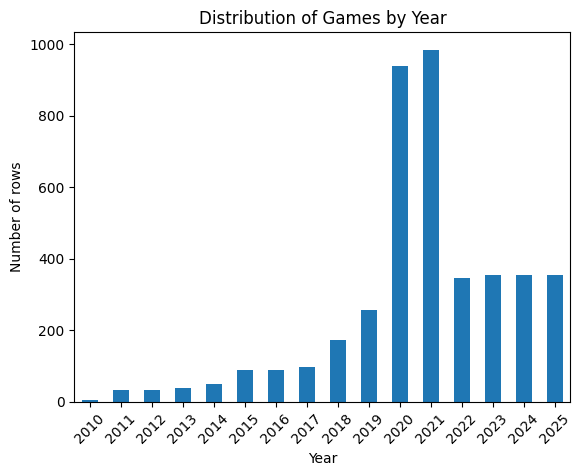

In [ ]:
import matplotlib.pyplot as plt

df['Year'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Rows by Year')
plt.xlabel('Year')
plt.ylabel('Number of rows')
plt.xticks(rotation=45)
plt.show()

#### Notes on Year

**What I found**  
- I found that the number of rows is highly uneven across years.  
- From 2010 to 2019, the row counts generally increase over time, but 2020 and 2021 show a very large jump compared with all earlier years.  
- After that peak, the row counts drop in 2022 and then remain relatively stable from 2022 to 2025.  
- This supports my earlier finding that 2020 and 2021 should be treated as special pandemic-era years with a different competition structure.

**What I did not find**  
- I did not find a balanced year distribution.  
- I also did not find evidence that raw row counts can be compared across years without considering changes in tournament format.

**Working decision**  
- I will treat Year as both a time variable and a context variable.  
- I will be careful with year-based comparisons, especially for 2020 and 2021, because structural changes in the competition likely affect row counts.  
- I will keep Year as a core variable for later analysis.

In [58]:
df["Round"].value_counts(dropna=False)

Round
Top 32    712
Top 64    626
WQ        514
Top 16    382
Top 8     366
L T8      256
WS        252
LQ        246
Semis     184
WF        130
GF        128
LS        126
LF        124
Finals    122
GFBR       34
Name: count, dtype: int64

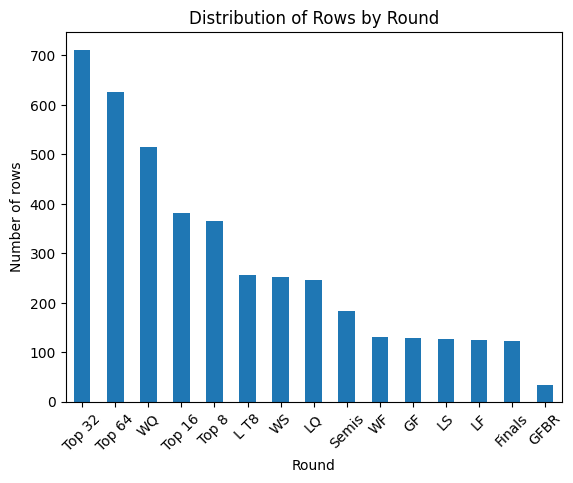

In [83]:
df["Round"].value_counts(dropna=False).plot(kind="bar")
plt.title("Distribution of Rows by Round")
plt.xlabel("Round")
plt.ylabel("Number of rows")
plt.xticks(rotation=45)
plt.show()

In [84]:
pd.crosstab(df["Year"], df["Round"])

Round,Finals,GF,GFBR,L T8,LF,LQ,LS,Semis,Top 16,Top 32,Top 64,Top 8,WF,WQ,WS
Year,,,,,,,,,,,,,,,
2010,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2011,4,0,0,0,0,0,0,10,0,0,0,18,0,0,0
2012,6,0,0,0,0,0,0,10,0,0,0,18,0,0,0
2013,10,0,0,0,0,0,0,8,0,0,0,22,0,0,0
2014,8,0,0,0,0,0,0,8,10,4,0,20,0,0,0
2015,8,0,0,0,0,0,0,10,20,34,0,18,0,0,0
2016,8,0,0,0,0,0,0,10,18,34,0,20,0,0,0
2017,6,0,0,0,0,0,0,10,26,34,0,22,0,0,0
2018,6,0,0,0,0,0,0,12,34,70,34,18,0,0,0


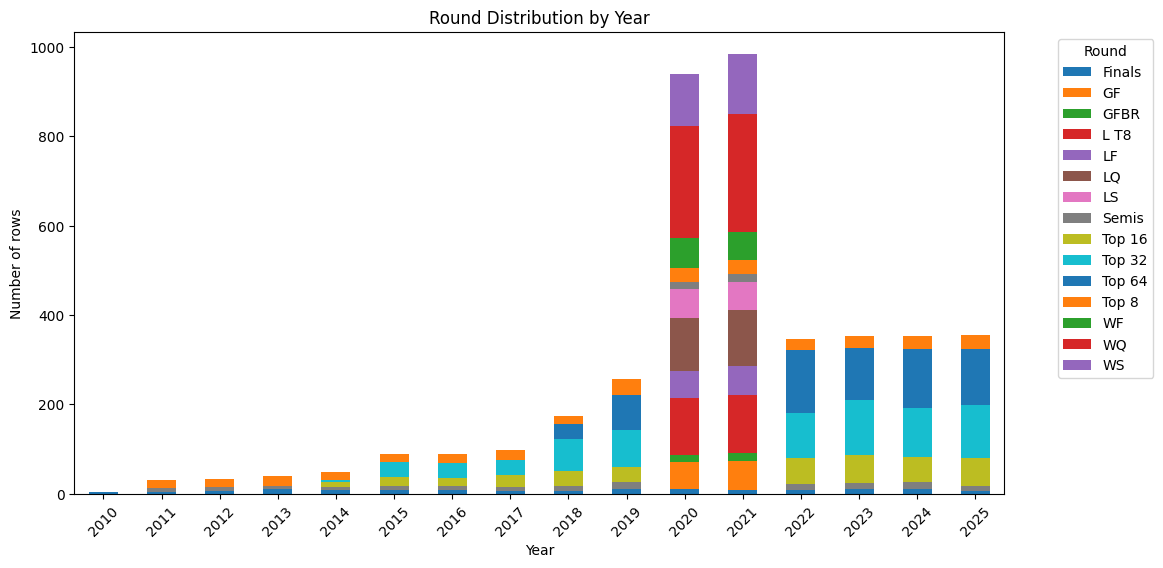

In [85]:
round_by_year = pd.crosstab(df["Year"], df["Round"])

round_by_year.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Round Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Number of rows")
plt.xticks(rotation=45)
plt.legend(title="Round", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

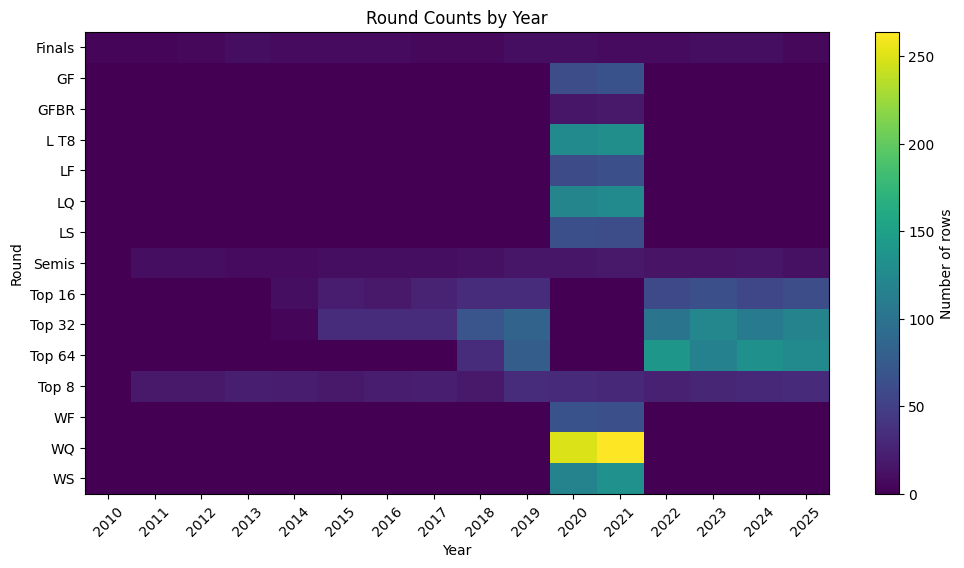

In [86]:
plt.figure(figsize=(12, 6))
plt.imshow(round_by_year.T, aspect='auto')
plt.colorbar(label='Number of rows')

plt.xticks(ticks=range(len(round_by_year.index)), labels=round_by_year.index, rotation=45)
plt.yticks(ticks=range(len(round_by_year.columns)), labels=round_by_year.columns)

plt.title('Round Counts by Year')
plt.xlabel('Year')
plt.ylabel('Round')
plt.show()

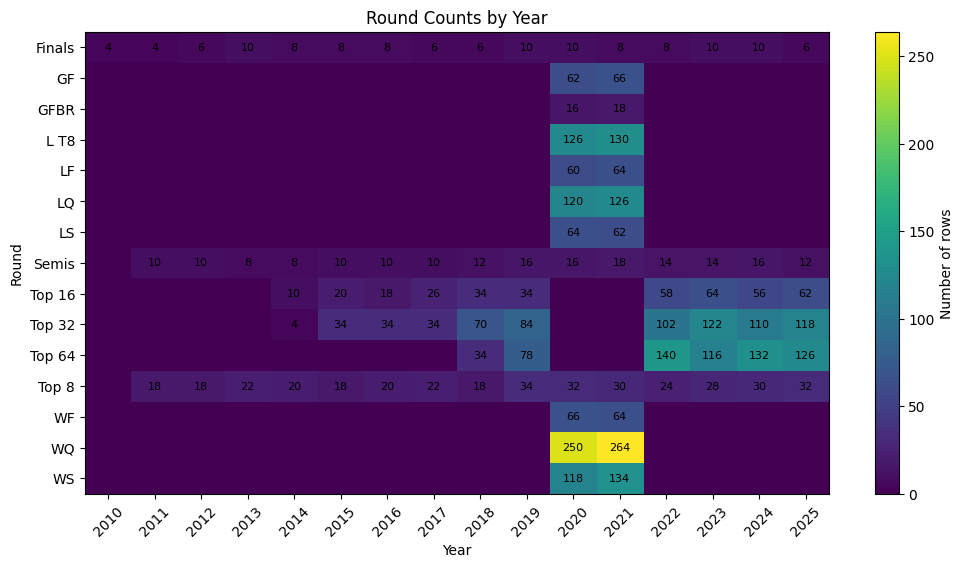

In [87]:
plt.figure(figsize=(12, 6))
plt.imshow(round_by_year.T, aspect='auto')
plt.colorbar(label='Number of rows')

plt.xticks(ticks=range(len(round_by_year.index)), labels=round_by_year.index, rotation=45)
plt.yticks(ticks=range(len(round_by_year.columns)), labels=round_by_year.columns)

for i in range(round_by_year.T.shape[0]):
    for j in range(round_by_year.T.shape[1]):
        value = round_by_year.T.iloc[i, j]
        if value != 0:
            plt.text(j, i, str(value), ha='center', va='center', fontsize=8)

plt.title('Round Counts by Year')
plt.xlabel('Year')
plt.ylabel('Round')
plt.show()

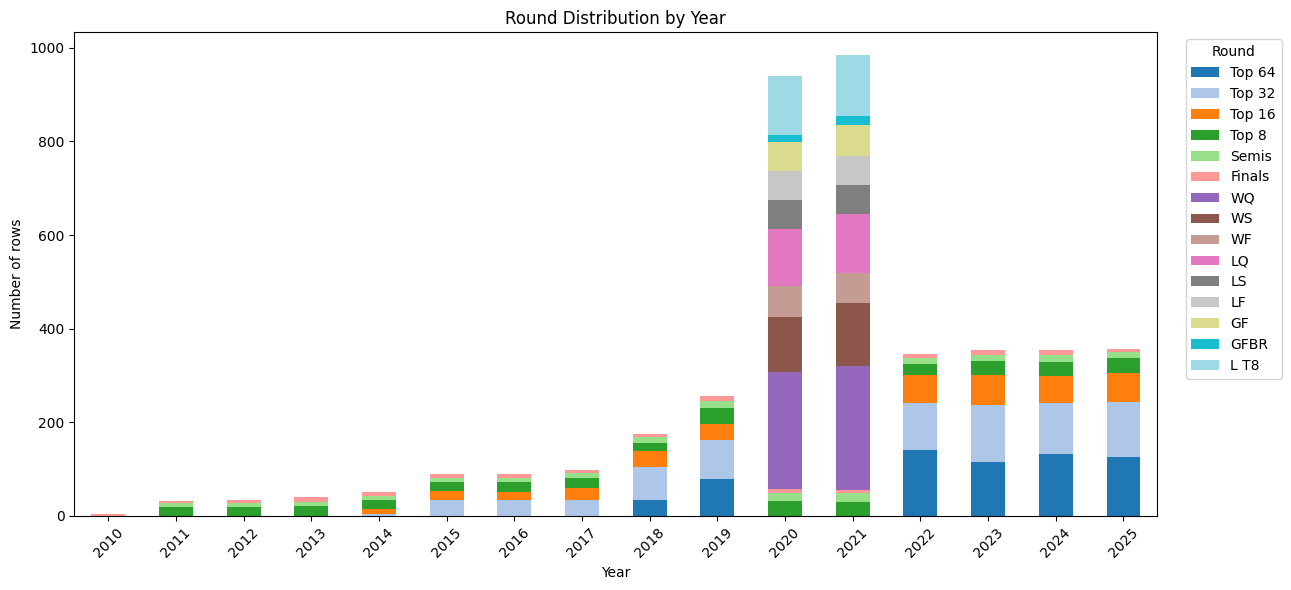

In [89]:

round_order = [
    "Top 64", "Top 32", "Top 16", "Top 8", "Semis", "Finals",
    "WQ", "WS", "WF", "LQ", "LS", "LF", "GF", "GFBR", "L T8"
]

round_by_year = pd.crosstab(df["Year"], df["Round"])

# only keep rounds that actually exist in the data, in your chosen order
round_order_present = [r for r in round_order if r in round_by_year.columns]
round_by_year = round_by_year[round_order_present]

cmap = plt.get_cmap("tab20")
colors = [cmap(i) for i in np.linspace(0, 1, len(round_order_present))]

round_by_year.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 6),
    color=colors
)

plt.title("Round Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Number of rows")
plt.xticks(rotation=45)
plt.legend(title="Round", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Note on Round

**What I found**  
- I found that the `Round` column contains labels from different tournament structures across different years.  
- Standard round names appear, including `Top 64`, `Top 32`, `Top 16`, `Top 8`, `Semis`, and `Finals`.  
- I also identified abbreviated round names linked to the pandemic-era online format:  
  - `WQ` = Winners Quarters  
  - `WS` = Winners Semis  
  - `WF` = Winners Finals  
  - `LQ` = Losers Quarters  
  - `LS` = Losers Semis  
  - `LF` = Losers Finals  
  - `GF` = Grand Finals  
- I found that these abbreviated round labels appear only in 2020 and 2021, which confirms that those years used a different competition structure.  
- In 2020 and 2021, CTWC used an online format with a group-stage structure. The top 64 players were split into 8 groups of 8 players.  
- Inside each group, players moved through a double-elimination bracket:  
  - players started on the winners side  
  - if they lost once, they moved to the losers side  
  - if they lost again, they were eliminated  
- Each group produced one winner.  
- The 8 group winners then advanced to a later `Top 8` stage, where the final championship bracket was played.  
- This means the `Round` column combines standard in-person bracket rounds with pandemic-era online double-elimination group-stage rounds.  
- The year-by-round crosstab and stacked bar chart show clearly that 2020 and 2021 have a different round structure from the other years.  
- The most frequent round labels overall are `Top 32`, `Top 64`, and `WQ`, but these totals should be interpreted carefully because they reflect different tournament formats.

**What I did not find**  
- I did not confirm the exact official meaning of `L T8`.  
- I did not confirm the exact official meaning of `GFBR`.  
- I did not document the full tournament-format history year by year inside the notebook.

**Working decision**  
- I will keep `Round` in the dataset.  
- I will treat it as a valid mixed-format competition-structure column.  
- I will be careful when comparing rounds across all years, because the tournament structure changed over time.  
- I will interpret `Round` together with `Year`, especially for 2020 and 2021.  
- If needed later, I may group rounds into broader categories for cleaner analysis.  
- I should contact CTWC to confirm the meanings of `L T8` and `GFBR`.

In [59]:
df["Won?"].value_counts(dropna=False)

Won?
Yes    2101
No     2101
Name: count, dtype: int64

In [60]:
df["Playstyle"].value_counts(dropna=False)

Playstyle
Tap     1721
Roll    1316
DAS     1165
Name: count, dtype: int64

In [65]:
pd.crosstab(df["Year"], df["Playstyle"])

Playstyle,DAS,Roll,Tap
Year,,,
2010,4,0,0
2011,32,0,0
2012,34,0,0
2013,40,0,0
2014,50,0,0
2015,90,0,0
2016,82,0,8
2017,95,0,3
2018,152,0,22


In [67]:
pd.crosstab(df["Year"], df["Playstyle"], normalize="index").round(3)

Playstyle,DAS,Roll,Tap
Year,,,
2010,1.000,0.000,0.000
2011,1.000,0.000,0.000
2012,1.000,0.000,0.000
2013,1.000,0.000,0.000
2014,1.000,0.000,0.000
2015,1.000,0.000,0.000
2016,0.911,0.000,0.089
2017,0.969,0.000,0.031
2018,0.874,0.000,0.126


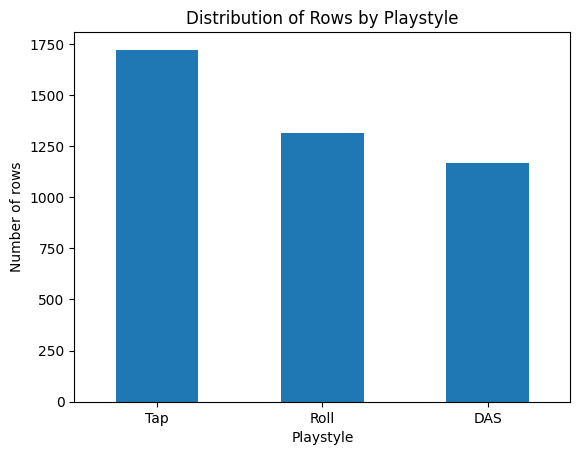

In [90]:
df["Playstyle"].value_counts(dropna=False).plot(kind="bar")
plt.title("Distribution of Rows by Playstyle")
plt.xlabel("Playstyle")
plt.ylabel("Number of rows")
plt.xticks(rotation=0)
plt.show()

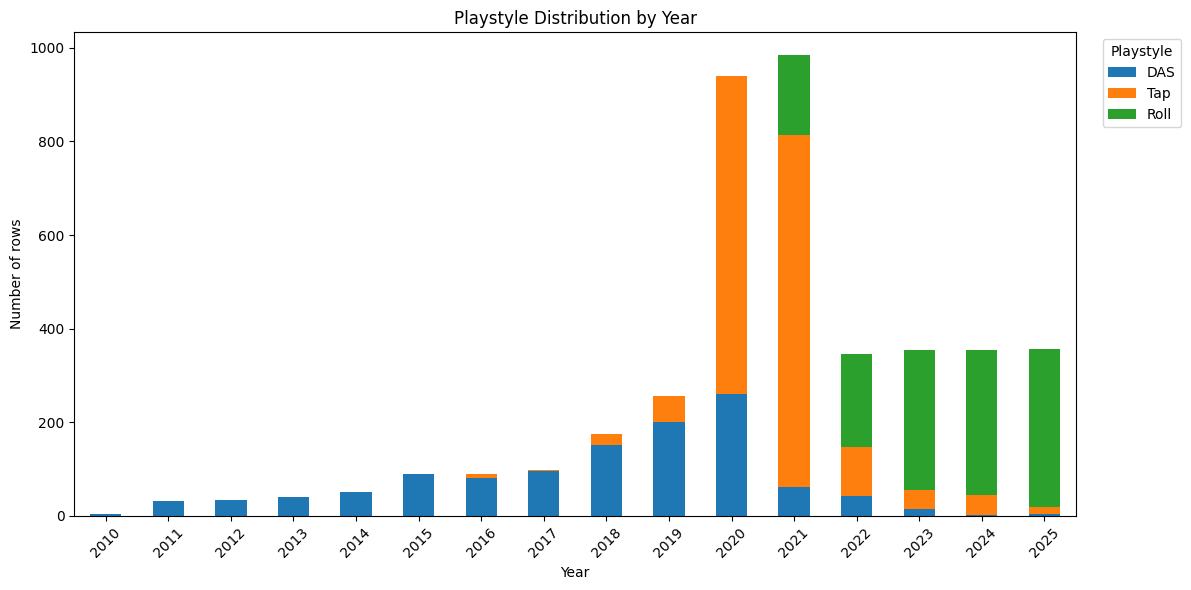

In [91]:
playstyle_by_year = pd.crosstab(df["Year"], df["Playstyle"])

playstyle_order = ["DAS", "Tap", "Roll"]
playstyle_order_present = [p for p in playstyle_order if p in playstyle_by_year.columns]
playstyle_by_year = playstyle_by_year[playstyle_order_present]

playstyle_by_year.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Playstyle Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Number of rows")
plt.xticks(rotation=45)
plt.legend(title="Playstyle", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

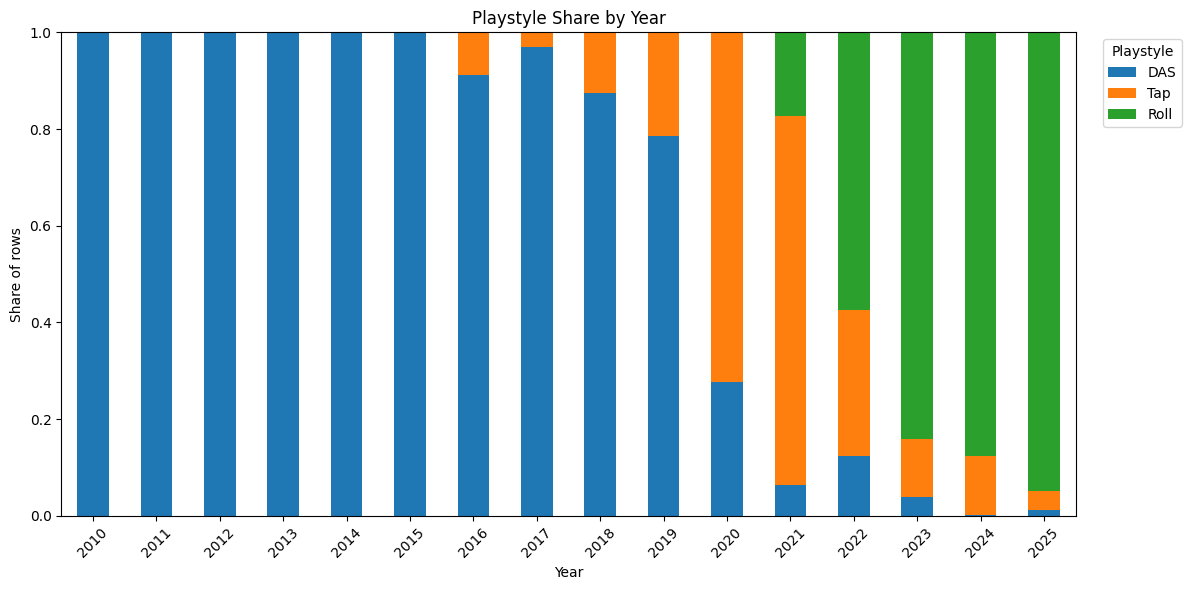

In [92]:
playstyle_by_year_norm = pd.crosstab(df["Year"], df["Playstyle"], normalize="index")
playstyle_by_year_norm = playstyle_by_year_norm[playstyle_order_present]

playstyle_by_year_norm.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Playstyle Share by Year")
plt.xlabel("Year")
plt.ylabel("Share of rows")
plt.xticks(rotation=45)
plt.legend(title="Playstyle", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Note on Playstyle

**What I found**  
- I found that `Playstyle` is one of the most informative columns for showing how CTWC changed over time.  
- The dataset contains three playstyles: `DAS`, `Tap`, and `Roll`.  
- The total row counts are `Tap` = 1721, `Roll` = 1316, and `DAS` = 1165.  
- The year-by-year distribution shows a very clear evolution in playstyle:  
  - from 2010 to 2015, all recorded games use `DAS`  
  - from 2016 to 2019, `Tap` begins to appear, but `DAS` remains the dominant playstyle  
  - in 2020 and 2021, `Tap` becomes the dominant playstyle  
  - in 2021, `Roll` appears in the dataset  
  - from 2022 onward, `Roll` becomes the dominant playstyle  
  - by 2025, `Roll` makes up almost the entire dataset  
- The normalized year-by-year table makes this transition especially clear, because it shows that the dominant playstyle changes by era rather than just by total row count.  
- This makes `Playstyle` one of the clearest indicators of gameplay evolution in the project.

**What I did not find**  
- I did not investigate the technical gameplay details of each playstyle in this notebook section.  
- I did not test yet how strongly `Playstyle` is linked to score, transitions, topout type, or match outcomes.  
- I also did not treat `Playstyle` as independent from time, because the results clearly show that it is strongly linked to year.

**Working decision**  
- I will keep `Playstyle` in the dataset.  
- I will treat it as a core analysis column.  
- I will use it later to help explain how competitive play changed over time.  
- When comparing playstyle to performance variables, I will interpret it together with `Year`, because playstyle is strongly tied to era.

In [61]:
df["Topout Type"].value_counts(dropna=False)

Topout Type
Natural        2726
Intentional    1455
Aggressive       20
NaN               1
Name: count, dtype: int64

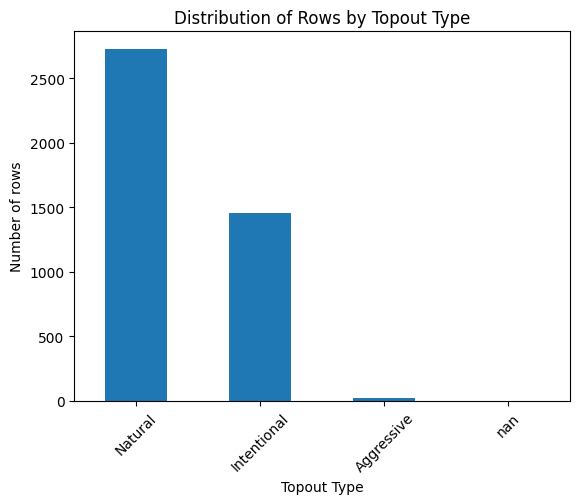

In [95]:
df["Topout Type"].value_counts(dropna=False).plot(kind="bar")
plt.title("Distribution of Rows by Topout Type")
plt.xlabel("Topout Type")
plt.ylabel("Number of rows")
plt.xticks(rotation=45)
plt.show()

In [69]:
df[df["Topout Type"] == "Aggressive"]["Year"].value_counts().sort_index()

Year
2012    1
2017    1
2020    3
2021    6
2023    2
2024    2
2025    5
Name: count, dtype: int64

In [96]:
pd.crosstab(df["Year"], df["Topout Type"], dropna=False)

Topout Type,Aggressive,Intentional,Natural,NaN
Year,,,,
2010,0,1,3,0
2011,0,14,18,0
2012,1,14,19,0
2013,0,14,26,0
2014,0,21,29,0
2015,0,36,54,0
2016,0,36,54,0
2017,1,40,57,0
2018,0,71,103,0


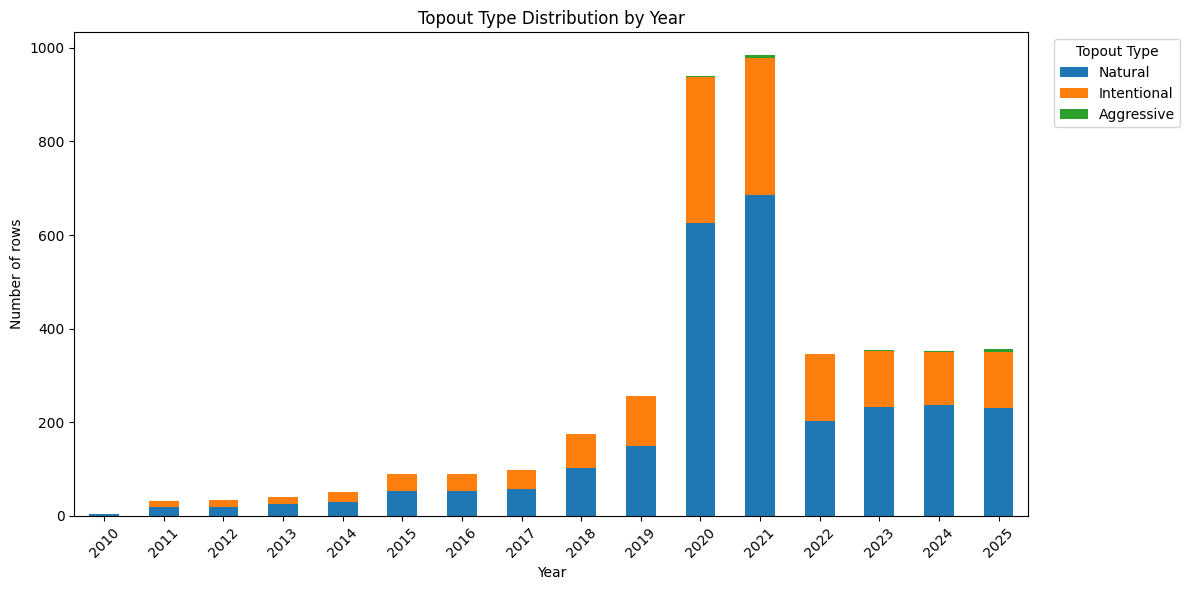

In [97]:
topout_by_year = pd.crosstab(df["Year"], df["Topout Type"], dropna=False)

topout_order = ["Natural", "Intentional", "Aggressive"]
topout_order_present = [t for t in topout_order if t in topout_by_year.columns]
topout_by_year = topout_by_year[topout_order_present]

topout_by_year.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Topout Type Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Number of rows")
plt.xticks(rotation=45)
plt.legend(title="Topout Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

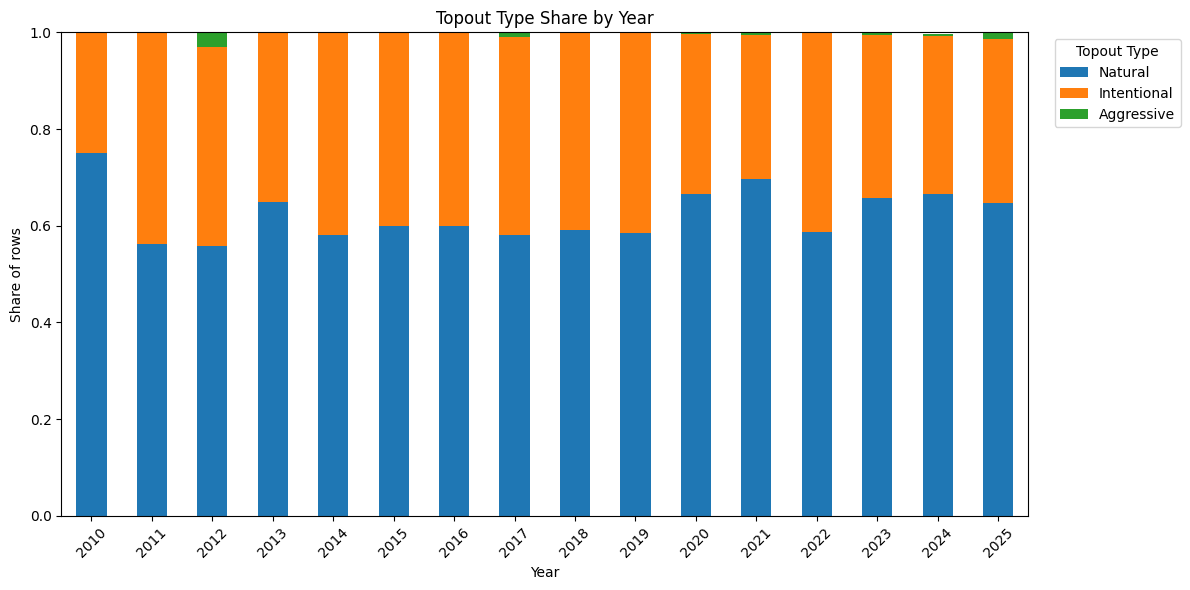

In [98]:
topout_by_year_norm = pd.crosstab(df["Year"], df["Topout Type"], normalize="index", dropna=False)
topout_by_year_norm = topout_by_year_norm[topout_order_present]

topout_by_year_norm.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Topout Type Share by Year")
plt.xlabel("Year")
plt.ylabel("Share of rows")
plt.xticks(rotation=45)
plt.legend(title="Topout Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Note on Topout Type

**What I found**  
- I found that `Topout Type` contains `Natural`, `Intentional`, and `Aggressive`, plus 1 missing value.  
- `Natural` is the most common topout type, `Intentional` is the second most common, and `Aggressive` is very rare with only 20 rows.  
- `Aggressive` appears in multiple years, but only in very small numbers.  
- The overall pattern is fairly stable across years.

**What I did not find**  
- I did not find an official CTWC definition of `Aggressive`.  
- I also did not investigate yet how `Topout Type` relates to score, playstyle, or win/loss outcomes.

**Working decision**  
- I will keep `Topout Type` in the dataset.  
- I will treat `Aggressive` as a working interpretation, not an official CTWC-confirmed definition.  
- I should contact CTWC if I need the exact official meaning later.

In [62]:
df["Level"].value_counts(dropna=False)

Level
18    4152
15      24
9       20
13       6
Name: count, dtype: int64

In [99]:
pd.crosstab(df["Year"], df["Level"])

Level,9,13,15,18
Year,,,,
2010,4,0,0,0
2011,0,0,0,32
2012,10,2,0,22
2013,0,4,0,36
2014,0,0,0,50
2015,6,0,2,82
2016,0,0,6,84
2017,0,0,4,94
2018,0,0,8,166


In [100]:
pd.crosstab(df["Year"], df["Level"], normalize="index").round(3)

Level,9,13,15,18
Year,,,,
2010,1.000,0.000,0.000,0.000
2011,0.000,0.000,0.000,1.000
2012,0.294,0.059,0.000,0.647
2013,0.000,0.100,0.000,0.900
2014,0.000,0.000,0.000,1.000
2015,0.067,0.000,0.022,0.911
2016,0.000,0.000,0.067,0.933
2017,0.000,0.000,0.041,0.959
2018,0.000,0.000,0.046,0.954


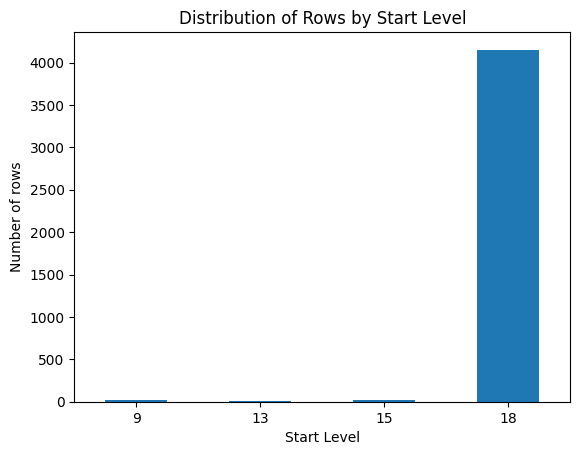

In [101]:
df["Level"].value_counts(dropna=False).sort_index().plot(kind="bar")
plt.title("Distribution of Rows by Start Level")
plt.xlabel("Start Level")
plt.ylabel("Number of rows")
plt.xticks(rotation=0)
plt.show()

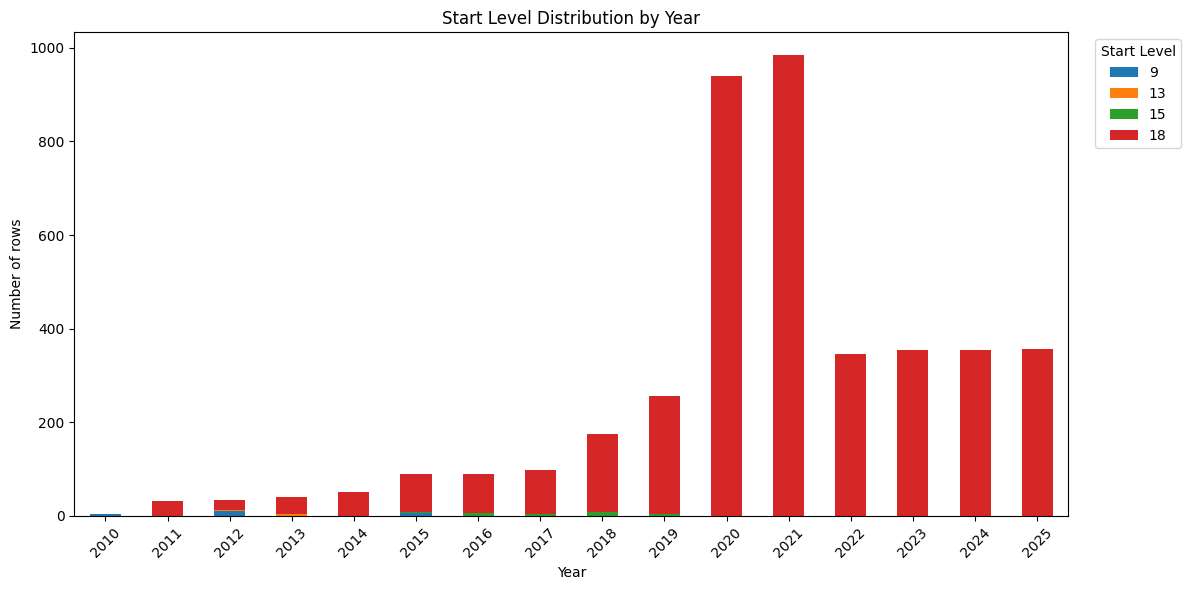

In [102]:
level_by_year = pd.crosstab(df["Year"], df["Level"])

level_order = [9, 13, 15, 18]
level_order_present = [lvl for lvl in level_order if lvl in level_by_year.columns]
level_by_year = level_by_year[level_order_present]

level_by_year.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Start Level Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Number of rows")
plt.xticks(rotation=45)
plt.legend(title="Start Level", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [103]:
pd.crosstab(df["Round"], df["Level"])

Level,9,13,15,18
Round,,,,
Finals,6,0,0,116
GF,0,0,0,128
GFBR,0,0,0,34
L T8,0,0,0,256
LF,0,0,0,124
LQ,0,0,0,246
LS,0,0,0,126
Semis,2,0,0,182
Top 16,2,0,0,380


In [104]:
pd.crosstab(df["Round"], df["Level"], normalize="index").round(3)

Level,9,13,15,18
Round,,,,
Finals,0.049,0.000,0.000,0.951
GF,0.000,0.000,0.000,1.000
GFBR,0.000,0.000,0.000,1.000
L T8,0.000,0.000,0.000,1.000
LF,0.000,0.000,0.000,1.000
LQ,0.000,0.000,0.000,1.000
LS,0.000,0.000,0.000,1.000
Semis,0.011,0.000,0.000,0.989
Top 16,0.005,0.000,0.000,0.995


In [105]:
round_order = [
    "Top 64", "Top 32", "Top 16", "Top 8", "Semis", "Finals",
    "WQ", "WS", "WF", "LQ", "LS", "LF", "GF", "GFBR", "L T8"
]

round_level = pd.crosstab(df["Round"], df["Level"])
round_level = round_level.reindex([r for r in round_order if r in round_level.index])

round_level

Level,9,13,15,18
Round,,,,
Top 64,0,0,10,616
Top 32,4,0,14,694
Top 16,2,0,0,380
Top 8,6,6,0,354
Semis,2,0,0,182
Finals,6,0,0,116
WQ,0,0,0,514
WS,0,0,0,252
WF,0,0,0,130


In [106]:
round_level_norm = pd.crosstab(df["Round"], df["Level"], normalize="index").round(3)
round_level_norm = round_level_norm.reindex([r for r in round_order if r in round_level_norm.index])

round_level_norm

Level,9,13,15,18
Round,,,,
Top 64,0.000,0.000,0.016,0.984
Top 32,0.006,0.000,0.020,0.975
Top 16,0.005,0.000,0.000,0.995
Top 8,0.016,0.016,0.000,0.967
Semis,0.011,0.000,0.000,0.989
Finals,0.049,0.000,0.000,0.951
WQ,0.000,0.000,0.000,1.000
WS,0.000,0.000,0.000,1.000
WF,0.000,0.000,0.000,1.000


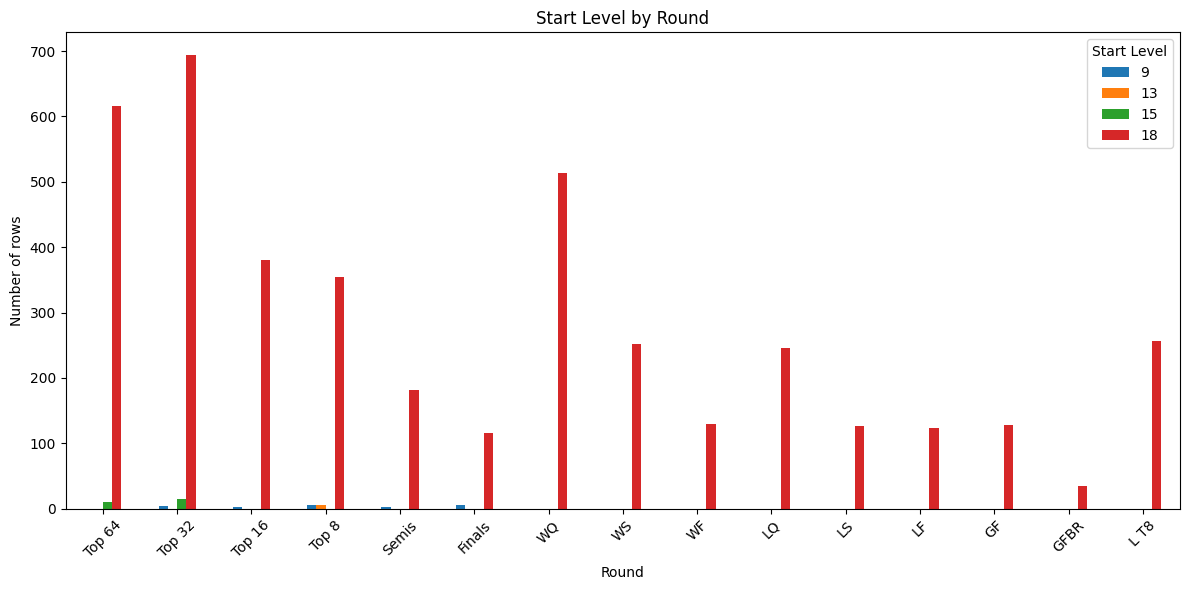

In [107]:
round_level.plot(kind="bar", figsize=(12, 6))
plt.title("Start Level by Round")
plt.xlabel("Round")
plt.ylabel("Number of rows")
plt.xticks(rotation=45)
plt.legend(title="Start Level")
plt.tight_layout()
plt.show()

In [108]:
df.groupby(["Year", "Round", "Level"]).size().unstack(fill_value=0)

Level        9   13  15   18
Year Round                  
2010 Finals   4   0   0    0
2011 Finals   0   0   0    4
     Semis    0   0   0   10
     Top 8    0   0   0   18
2012 Finals   2   0   0    4
     Semis    2   0   0    8
     Top 8    6   2   0   10
2013 Finals   0   0   0   10
     Semis    0   0   0    8
     Top 8    0   4   0   18
2014 Finals   0   0   0    8
     Semis    0   0   0    8
     Top 16   0   0   0   10
     Top 32   0   0   0    4
     Top 8    0   0   0   20
2015 Finals   0   0   0    8
     Semis    0   0   0   10
     Top 16   2   0   0   18
     Top 32   4   0   2   28
     Top 8    0   0   0   18
2016 Finals   0   0   0    8
     Semis    0   0   0   10
     Top 16   0   0   0   18
     Top 32   0   0   6   28
     Top 8    0   0   0   20
2017 Finals   0   0   0    6
     Semis    0   0   0   10
     Top 16   0   0   0   26
     Top 32   0   0   4   30
     Top 8    0   0   0   22
2018 Finals   0   0   0    6
     Semis    0   0   0   12
     Top 16   0   0   0   34
     Top 32   0   0   2   68
     Top 64   0   0   6   28
     Top 8    0   0   0   18
2019 Finals   0   0   0   10
     Semis    0   0   0   16
     Top 16   0   0   0   34
     Top 32   0   0   0   84
     Top 64   0   0   4   74
     Top 8    0   0   0   34
2020 Finals   0   0   0   10
     GF       0   0   0   62
     GFBR     0   0   0   16
     L T8     0   0   0  126
     LF       0   0   0   60
     LQ       0   0   0  120
     LS       0   0   0   64
     Semis    0   0   0   16
     Top 8    0   0   0   32
     WF       0   0   0   66
     WQ       0   0   0  250
     WS       0   0   0  118
2021 Finals   0   0   0    8
     GF       0   0   0   66
     GFBR     0   0   0   18
     L T8     0   0   0  130
     LF       0   0   0   64
     LQ       0   0   0  126
     LS       0   0   0   62
     Semis    0   0   0   18
     Top 8    0   0   0   30
     WF       0   0   0   64
     WQ       0   0   0  264
     WS       0   0   0  134
2022 Finals   0   0   0    8
     Semis    0   0   0   14
     Top 16   0   0   0   58
     Top 32   0   0   0  102
     Top 64   0   0   0  140
     Top 8    0   0   0   24
2023 Finals   0   0   0   10
     Semis    0   0   0   14
     Top 16   0   0   0   64
     Top 32   0   0   0  122
     Top 64   0   0   0  116
     Top 8    0   0   0   28
2024 Finals   0   0   0   10
     Semis    0   0   0   16
     Top 16   0   0   0   56
     Top 32   0   0   0  110
     Top 64   0   0   0  132
     Top 8    0   0   0   30
2025 Finals   0   0   0    6
     Semis    0   0   0   12
     Top 16   0   0   0   62
     Top 32   0   0   0  118
     Top 64   0   0   0  126
     Top 8    0   0   0   32

In [109]:
round_order = [
    "Top 64", "Top 32", "Top 16", "Top 8", "Semis", "Finals",
    "WQ", "WS", "WF", "LQ", "LS", "LF", "GF", "GFBR", "L T8"
]

year_round_level = df.groupby(["Year", "Round", "Level"]).size().unstack(fill_value=0)

# reorder rounds inside the multiindex
existing_rounds = [r for r in round_order if r in year_round_level.index.get_level_values("Round")]
year_round_level = year_round_level.reindex(
    [(y, r) for y in sorted(df["Year"].unique()) for r in existing_rounds if (y, r) in year_round_level.index]
)

year_round_level

Level        9   13  15   18
Year Round                  
2010 Finals   4   0   0    0
2011 Top 8    0   0   0   18
     Semis    0   0   0   10
     Finals   0   0   0    4
2012 Top 8    6   2   0   10
     Semis    2   0   0    8
     Finals   2   0   0    4
2013 Top 8    0   4   0   18
     Semis    0   0   0    8
     Finals   0   0   0   10
2014 Top 32   0   0   0    4
     Top 16   0   0   0   10
     Top 8    0   0   0   20
     Semis    0   0   0    8
     Finals   0   0   0    8
2015 Top 32   4   0   2   28
     Top 16   2   0   0   18
     Top 8    0   0   0   18
     Semis    0   0   0   10
     Finals   0   0   0    8
2016 Top 32   0   0   6   28
     Top 16   0   0   0   18
     Top 8    0   0   0   20
     Semis    0   0   0   10
     Finals   0   0   0    8
2017 Top 32   0   0   4   30
     Top 16   0   0   0   26
     Top 8    0   0   0   22
     Semis    0   0   0   10
     Finals   0   0   0    6
2018 Top 64   0   0   6   28
     Top 32   0   0   2   68
     Top 16   0   0   0   34
     Top 8    0   0   0   18
     Semis    0   0   0   12
     Finals   0   0   0    6
2019 Top 64   0   0   4   74
     Top 32   0   0   0   84
     Top 16   0   0   0   34
     Top 8    0   0   0   34
     Semis    0   0   0   16
     Finals   0   0   0   10
2020 Top 8    0   0   0   32
     Semis    0   0   0   16
     Finals   0   0   0   10
     WQ       0   0   0  250
     WS       0   0   0  118
     WF       0   0   0   66
     LQ       0   0   0  120
     LS       0   0   0   64
     LF       0   0   0   60
     GF       0   0   0   62
     GFBR     0   0   0   16
     L T8     0   0   0  126
2021 Top 8    0   0   0   30
     Semis    0   0   0   18
     Finals   0   0   0    8
     WQ       0   0   0  264
     WS       0   0   0  134
     WF       0   0   0   64
     LQ       0   0   0  126
     LS       0   0   0   62
     LF       0   0   0   64
     GF       0   0   0   66
     GFBR     0   0   0   18
     L T8     0   0   0  130
2022 Top 64   0   0   0  140
     Top 32   0   0   0  102
     Top 16   0   0   0   58
     Top 8    0   0   0   24
     Semis    0   0   0   14
     Finals   0   0   0    8
2023 Top 64   0   0   0  116
     Top 32   0   0   0  122
     Top 16   0   0   0   64
     Top 8    0   0   0   28
     Semis    0   0   0   14
     Finals   0   0   0   10
2024 Top 64   0   0   0  132
     Top 32   0   0   0  110
     Top 16   0   0   0   56
     Top 8    0   0   0   30
     Semis    0   0   0   16
     Finals   0   0   0   10
2025 Top 64   0   0   0  126
     Top 32   0   0   0  118
     Top 16   0   0   0   62
     Top 8    0   0   0   32
     Semis    0   0   0   12
     Finals   0   0   0    6

In [112]:
year_round_level_norm = pd.crosstab(
    [df["Year"], df["Round"]],
    df["Level"],
    normalize="index"
).round(2)

existing_rounds = [
    r for r in round_order
    if r in year_round_level_norm.index.get_level_values(1)
]

year_round_level_norm = year_round_level_norm.reindex(
    [(y, r) for y in sorted(df["Year"].unique()) for r in existing_rounds
     if (y, r) in year_round_level_norm.index]
)

year_round_level_norm

Level          9     13    15    18
Year Round                         
2010 Finals  1.00  0.00  0.00  0.00
2011 Top 8   0.00  0.00  0.00  1.00
     Semis   0.00  0.00  0.00  1.00
     Finals  0.00  0.00  0.00  1.00
2012 Top 8   0.33  0.11  0.00  0.56
     Semis   0.20  0.00  0.00  0.80
     Finals  0.33  0.00  0.00  0.67
2013 Top 8   0.00  0.18  0.00  0.82
     Semis   0.00  0.00  0.00  1.00
     Finals  0.00  0.00  0.00  1.00
2014 Top 32  0.00  0.00  0.00  1.00
     Top 16  0.00  0.00  0.00  1.00
     Top 8   0.00  0.00  0.00  1.00
     Semis   0.00  0.00  0.00  1.00
     Finals  0.00  0.00  0.00  1.00
2015 Top 32  0.12  0.00  0.06  0.82
     Top 16  0.10  0.00  0.00  0.90
     Top 8   0.00  0.00  0.00  1.00
     Semis   0.00  0.00  0.00  1.00
     Finals  0.00  0.00  0.00  1.00
2016 Top 32  0.00  0.00  0.18  0.82
     Top 16  0.00  0.00  0.00  1.00
     Top 8   0.00  0.00  0.00  1.00
     Semis   0.00  0.00  0.00  1.00
     Finals  0.00  0.00  0.00  1.00
2017 Top 32  0.00  0.00  0.12  0.88
     Top 16  0.00  0.00  0.00  1.00
     Top 8   0.00  0.00  0.00  1.00
     Semis   0.00  0.00  0.00  1.00
     Finals  0.00  0.00  0.00  1.00
2018 Top 64  0.00  0.00  0.18  0.82
     Top 32  0.00  0.00  0.03  0.97
     Top 16  0.00  0.00  0.00  1.00
     Top 8   0.00  0.00  0.00  1.00
     Semis   0.00  0.00  0.00  1.00
     Finals  0.00  0.00  0.00  1.00
2019 Top 64  0.00  0.00  0.05  0.95
     Top 32  0.00  0.00  0.00  1.00
     Top 16  0.00  0.00  0.00  1.00
     Top 8   0.00  0.00  0.00  1.00
     Semis   0.00  0.00  0.00  1.00
     Finals  0.00  0.00  0.00  1.00
2020 Top 8   0.00  0.00  0.00  1.00
     Semis   0.00  0.00  0.00  1.00
     Finals  0.00  0.00  0.00  1.00
     WQ      0.00  0.00  0.00  1.00
     WS      0.00  0.00  0.00  1.00
     WF      0.00  0.00  0.00  1.00
     LQ      0.00  0.00  0.00  1.00
     LS      0.00  0.00  0.00  1.00
     LF      0.00  0.00  0.00  1.00
     GF      0.00  0.00  0.00  1.00
     GFBR    0.00  0.00  0.00  1.00
     L T8    0.00  0.00  0.00  1.00
2021 Top 8   0.00  0.00  0.00  1.00
     Semis   0.00  0.00  0.00  1.00
     Finals  0.00  0.00  0.00  1.00
     WQ      0.00  0.00  0.00  1.00
     WS      0.00  0.00  0.00  1.00
     WF      0.00  0.00  0.00  1.00
     LQ      0.00  0.00  0.00  1.00
     LS      0.00  0.00  0.00  1.00
     LF      0.00  0.00  0.00  1.00
     GF      0.00  0.00  0.00  1.00
     GFBR    0.00  0.00  0.00  1.00
     L T8    0.00  0.00  0.00  1.00
2022 Top 64  0.00  0.00  0.00  1.00
     Top 32  0.00  0.00  0.00  1.00
     Top 16  0.00  0.00  0.00  1.00
     Top 8   0.00  0.00  0.00  1.00
     Semis   0.00  0.00  0.00  1.00
     Finals  0.00  0.00  0.00  1.00
2023 Top 64  0.00  0.00  0.00  1.00
     Top 32  0.00  0.00  0.00  1.00
     Top 16  0.00  0.00  0.00  1.00
     Top 8   0.00  0.00  0.00  1.00
     Semis   0.00  0.00  0.00  1.00
     Finals  0.00  0.00  0.00  1.00
2024 Top 64  0.00  0.00  0.00  1.00
     Top 32  0.00  0.00  0.00  1.00
     Top 16  0.00  0.00  0.00  1.00
     Top 8   0.00  0.00  0.00  1.00
     Semis   0.00  0.00  0.00  1.00
     Finals  0.00  0.00  0.00  1.00
2025 Top 64  0.00  0.00  0.00  1.00
     Top 32  0.00  0.00  0.00  1.00
     Top 16  0.00  0.00  0.00  1.00
     Top 8   0.00  0.00  0.00  1.00
     Semis   0.00  0.00  0.00  1.00
     Finals  0.00  0.00  0.00  1.00

### Note on Start Level

**What I found**  
- I found that the `Level` column is complete and contains the values `9`, `13`, `15`, and `18`.  
- Level 18 is by far the dominant value in the dataset.  
- The Year + Round + Level breakdown shows that before 2020, start levels were not fully standardized.  
- In the earlier years, some tournaments used multiple start levels within the same year and sometimes even within the same round.  
- From 2020 onward, all rows in the dataset use level 18, which shows a clear standardization from that point forward.  
- This means the column appears to represent the game’s start level and also captures a change in tournament setup over time.

**What I did not find**  
- I did not investigate the competitive reason behind the different start levels.  
- I also did not confirm why earlier years sometimes show multiple start levels within the same round.

**Working decision**  
- I will keep the column in the dataset.  
- I will rename `Level` to `Start Level` in the working analysis version to make the meaning clearer.  
- I will treat it as a useful setup/context column.  
- I will note that the dataset shows clear standardization to level 18 from 2020 onward.

In [63]:
df["Cap"].value_counts(dropna=False)

Cap
NaN        3138
39 KSx2    1064
Name: count, dtype: int64

In [114]:
pd.crosstab(df["Year"], df["Cap"], dropna=False)

Cap,39 KSx2,NaN
Year,,
2010,0,4
2011,0,32
2012,0,34
2013,0,40
2014,0,50
2015,0,90
2016,0,90
2017,0,98
2018,0,174


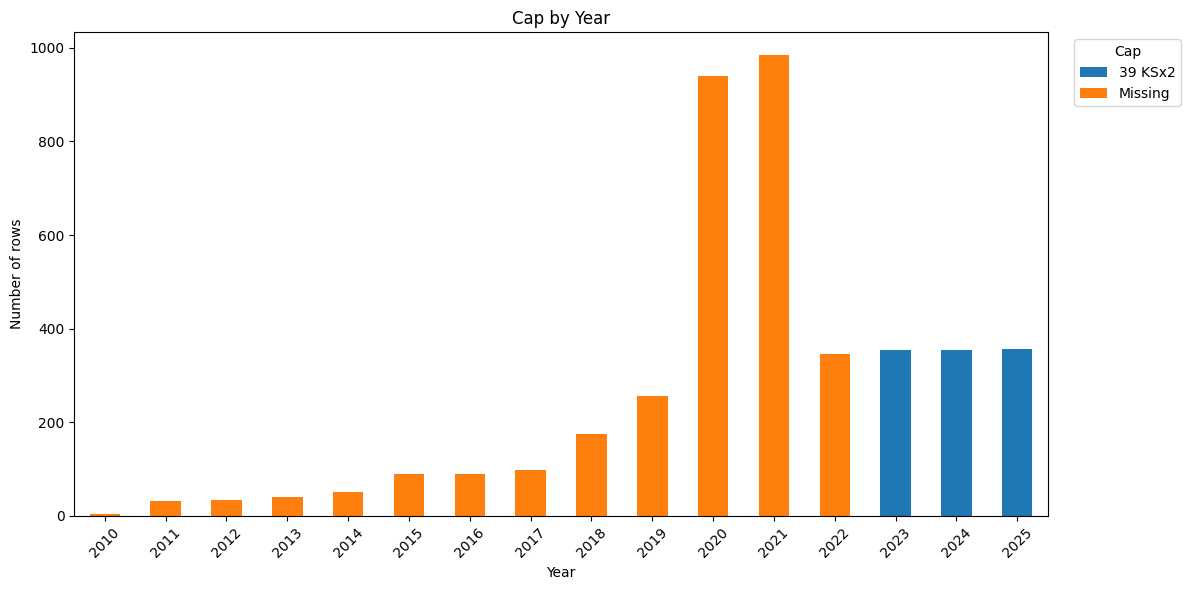

In [115]:
df_cap_plot = df.copy()
df_cap_plot["Cap"] = df_cap_plot["Cap"].fillna("Missing")

cap_by_year = pd.crosstab(df_cap_plot["Year"], df_cap_plot["Cap"])

cap_by_year.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Cap by Year")
plt.xlabel("Year")
plt.ylabel("Number of rows")
plt.xticks(rotation=45)
plt.legend(title="Cap", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Note on Cap

**What I found**  
- I found that `Cap` is missing in all rows from 2010 to 2022.  
- The column starts being recorded in 2023.  
- From 2023 onward, all rows use `39 KSx2`.

**What I did not find**  
- I did not find variation in `Cap` once the column starts being recorded.

**Working decision**  
- I will treat `Cap` as a field that was introduced or recorded only from 2023 onward, not as random missing data in earlier years.

In [64]:
df["SPS"].value_counts(dropna=False)

SPS
Yes    2142
No     2060
Name: count, dtype: int64

In [72]:
pd.crosstab(df["Round"], df["SPS"])

SPS,No,Yes
Round,,
Finals,40,82
GF,128,0
GFBR,34,0
L T8,256,0
LF,124,0
LQ,246,0
LS,126,0
Semis,46,138
Top 16,30,352


In [73]:
pd.crosstab(df["Round"], df["SPS"], normalize="index").round(3)

SPS,No,Yes
Round,,
Finals,0.328,0.672
GF,1.000,0.000
GFBR,1.000,0.000
L T8,1.000,0.000
LF,1.000,0.000
LQ,1.000,0.000
LS,1.000,0.000
Semis,0.250,0.750
Top 16,0.079,0.921


In [76]:
pd.set_option("display.max_rows", None)

In [77]:
# surprised, expected it to be more consistant. Lets check with also Year

(
    pd.crosstab([df["Year"], df["Round"]], df["SPS"], normalize="index")
    .round(3)
    .sort_index()
)

SPS           No  Yes
Year Round           
2010 Finals  1.0  0.0
2011 Finals  1.0  0.0
     Semis   1.0  0.0
     Top 8   1.0  0.0
2012 Finals  1.0  0.0
     Semis   1.0  0.0
     Top 8   1.0  0.0
2013 Finals  1.0  0.0
     Semis   1.0  0.0
     Top 8   1.0  0.0
2014 Finals  1.0  0.0
     Semis   1.0  0.0
     Top 16  1.0  0.0
     Top 32  1.0  0.0
     Top 8   1.0  0.0
2015 Finals  1.0  0.0
     Semis   1.0  0.0
     Top 16  1.0  0.0
     Top 32  1.0  0.0
     Top 8   1.0  0.0
2016 Finals  0.0  1.0
     Semis   0.0  1.0
     Top 16  0.0  1.0
     Top 32  0.0  1.0
     Top 8   0.0  1.0
2017 Finals  0.0  1.0
     Semis   0.0  1.0
     Top 16  0.0  1.0
     Top 32  0.0  1.0
     Top 8   0.0  1.0
2018 Finals  0.0  1.0
     Semis   0.0  1.0
     Top 16  0.0  1.0
     Top 32  0.0  1.0
     Top 64  0.0  1.0
     Top 8   0.0  1.0
2019 Finals  0.0  1.0
     Semis   0.0  1.0
     Top 16  0.0  1.0
     Top 32  0.0  1.0
     Top 64  0.0  1.0
     Top 8   0.0  1.0
2020 Finals  0.0  1.0
     GF      1.0  0.0
     GFBR    1.0  0.0
     L T8    1.0  0.0
     LF      1.0  0.0
     LQ      1.0  0.0
     LS      1.0  0.0
     Semis   0.0  1.0
     Top 8   0.0  1.0
     WF      1.0  0.0
     WQ      1.0  0.0
     WS      1.0  0.0
2021 Finals  0.0  1.0
     GF      1.0  0.0
     GFBR    1.0  0.0
     L T8    1.0  0.0
     LF      1.0  0.0
     LQ      1.0  0.0
     LS      1.0  0.0
     Semis   0.0  1.0
     Top 8   0.0  1.0
     WF      1.0  0.0
     WQ      1.0  0.0
     WS      1.0  0.0
2022 Finals  0.0  1.0
     Semis   0.0  1.0
     Top 16  0.0  1.0
     Top 32  0.0  1.0
     Top 64  0.0  1.0
     Top 8   0.0  1.0
2023 Finals  0.0  1.0
     Semis   0.0  1.0
     Top 16  0.0  1.0
     Top 32  0.0  1.0
     Top 64  0.0  1.0
     Top 8   0.0  1.0
2024 Finals  0.0  1.0
     Semis   0.0  1.0
     Top 16  0.0  1.0
     Top 32  0.0  1.0
     Top 64  0.0  1.0
     Top 8   0.0  1.0
2025 Finals  0.0  1.0
     Semis   0.0  1.0
     Top 16  0.0  1.0
     Top 32  0.0  1.0
     Top 64  0.0  1.0
     Top 8   0.0  1.0

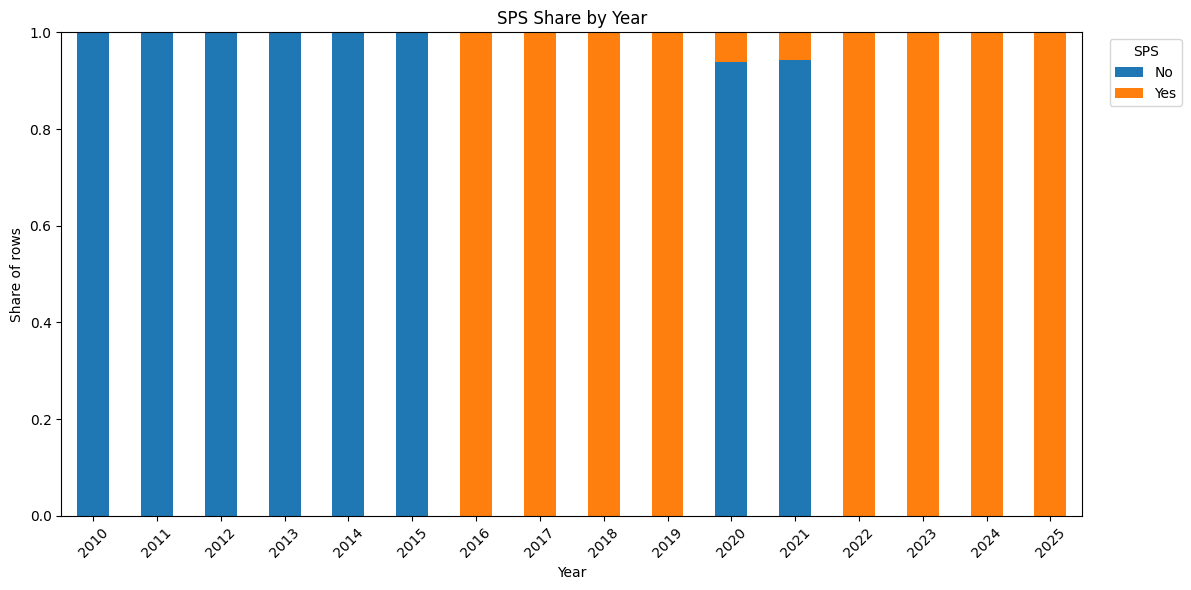

In [116]:
sps_by_year = pd.crosstab(df["Year"], df["SPS"], normalize="index").round(3)

sps_by_year.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("SPS Share by Year")
plt.xlabel("Year")
plt.ylabel("Share of rows")
plt.xticks(rotation=45)
plt.legend(title="SPS", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

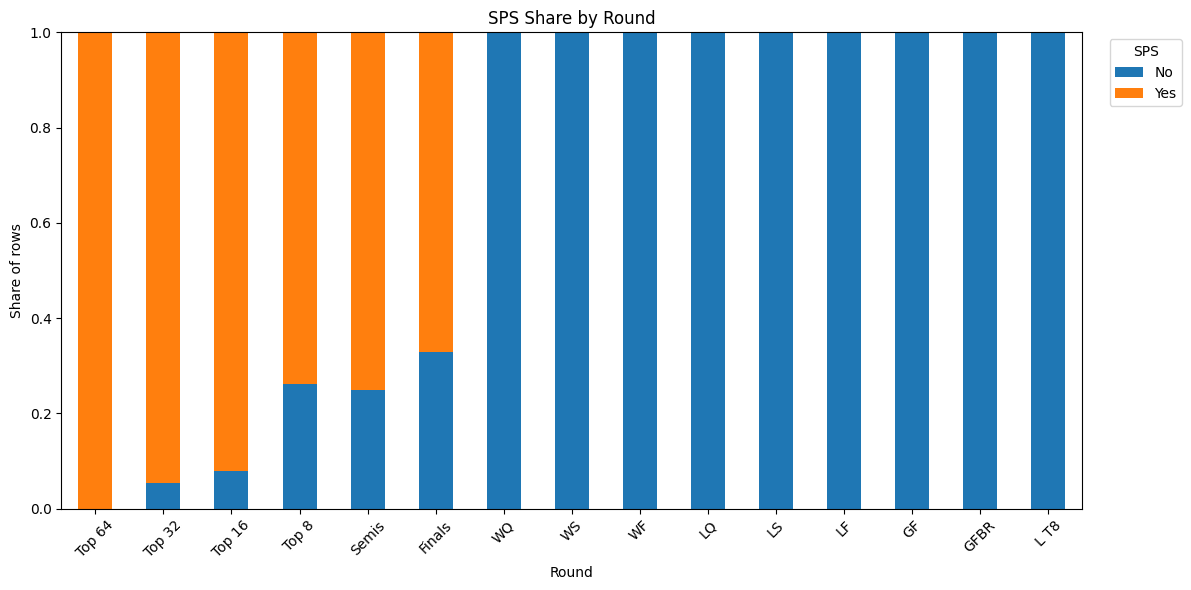

In [117]:
sps_by_round = pd.crosstab(df["Round"], df["SPS"], normalize="index").round(3)

round_order = [
    "Top 64", "Top 32", "Top 16", "Top 8", "Semis", "Finals",
    "WQ", "WS", "WF", "LQ", "LS", "LF", "GF", "GFBR", "L T8"
]

sps_by_round = sps_by_round.reindex([r for r in round_order if r in sps_by_round.index])

sps_by_round.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("SPS Share by Round")
plt.xlabel("Round")
plt.ylabel("Share of rows")
plt.xticks(rotation=45)
plt.legend(title="SPS", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

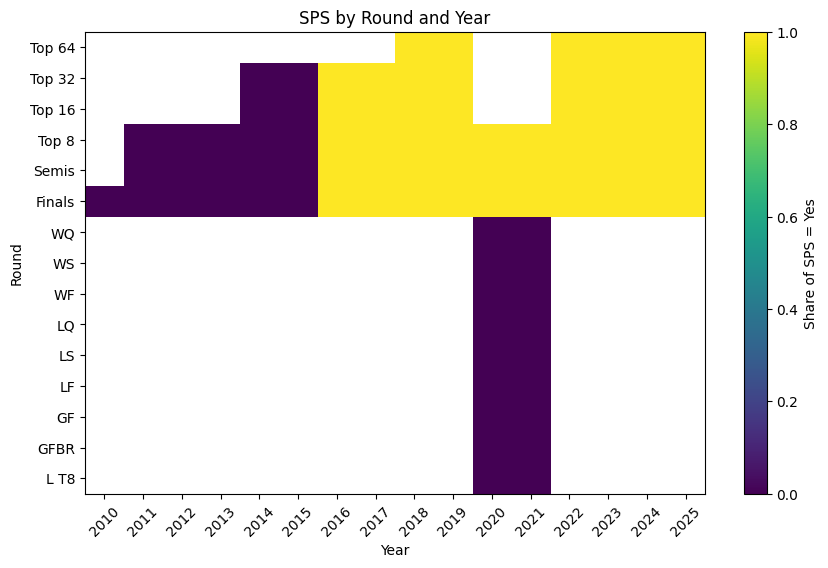

In [118]:
sps_num = df["SPS"].map({"No": 0, "Yes": 1})

sps_heatmap = (
    df.assign(SPS_num=sps_num)
      .pivot_table(
          index="Round",
          columns="Year",
          values="SPS_num",
          aggfunc="mean"
      )
)

round_order = [
    "Top 64", "Top 32", "Top 16", "Top 8", "Semis", "Finals",
    "WQ", "WS", "WF", "LQ", "LS", "LF", "GF", "GFBR", "L T8"
]

sps_heatmap = sps_heatmap.reindex([r for r in round_order if r in sps_heatmap.index])

plt.figure(figsize=(10, 6))
plt.imshow(sps_heatmap, aspect="auto", vmin=0, vmax=1)
plt.colorbar(label="Share of SPS = Yes")

plt.xticks(
    ticks=range(len(sps_heatmap.columns)),
    labels=sps_heatmap.columns,
    rotation=45
)
plt.yticks(
    ticks=range(len(sps_heatmap.index)),
    labels=sps_heatmap.index
)

plt.title("SPS by Round and Year")
plt.xlabel("Year")
plt.ylabel("Round")
plt.show()

### Notes on `SPS`

What I found:
- The `SPS` column has no missing values.
- From 2010 to 2015, all rows show `SPS = No`.
- From 2016 onward, the standard main-bracket rounds show `SPS = Yes`.
- In 2020 and 2021, the pandemic-era winners/losers group-stage rounds show `SPS = No`:
  - `WQ`
  - `WS`
  - `WF`
  - `LQ`
  - `LS`
  - `LF`
  - `GF`
  - `GFBR`
  - `L T8`
- In those same years, the more standard rounds such as `Top 8`, `Semis`, and `Finals` show `SPS = Yes`.
- This means the use of `SPS` follows a clear structural pattern by year and tournament format.

What I did not find:
- I did not confirm the exact tournament rule behind why `SPS` was used in some formats and not in others.
- I did not verify this pattern against official CTWC rule documentation.

Working decision:
- Keep `SPS` in the dataset.
- Treat it as a meaningful setup/rules column.
- Interpret it in relation to both year and tournament format.
- Contact CTWC later if I need the official rule explanation behind this pattern.

In [119]:
df["Final Score"].describe()

count    4.202000e+03
mean     6.854475e+05
std      3.407755e+05
min      0.000000e+00
25%      4.486735e+05
50%      6.766900e+05
75%      9.544378e+05
max      2.194440e+06
Name: Final Score, dtype: float64

In [120]:
df["Final Score"].isna().sum()

np.int64(0)

In [121]:
df["Final Score"].agg(["mean", "median", "min", "max"])

mean      6.854475e+05
median    6.766900e+05
min       0.000000e+00
max       2.194440e+06
Name: Final Score, dtype: float64

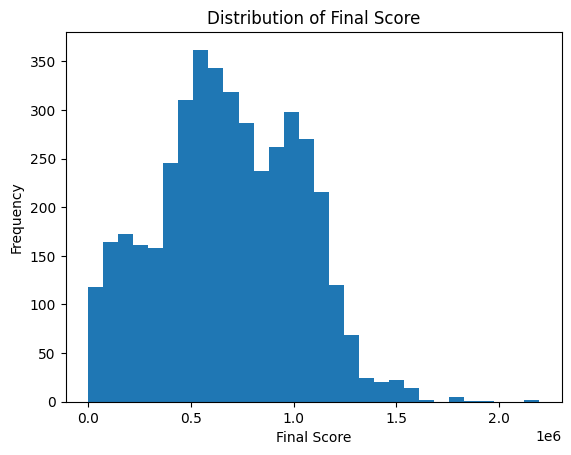

In [122]:
df["Final Score"].plot(kind="hist", bins=30)
plt.title("Distribution of Final Score")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.show()

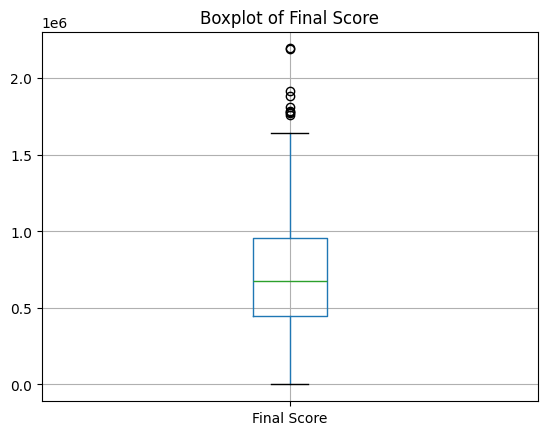

In [123]:
df.boxplot(column="Final Score")
plt.title("Boxplot of Final Score")
plt.show()

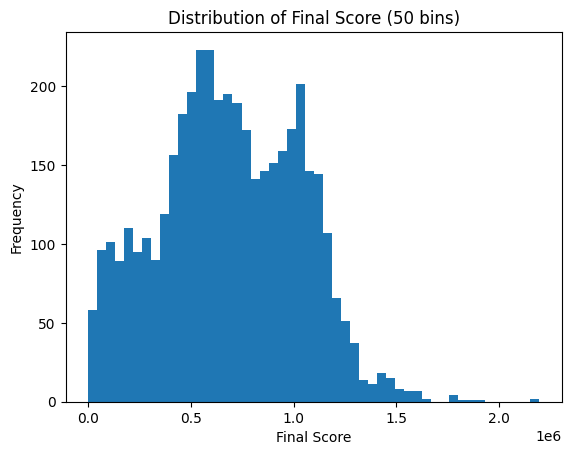

In [124]:
df["Final Score"].plot(kind="hist", bins=50)
plt.title("Distribution of Final Score (50 bins)")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.show()

In [125]:
df["Final Score"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25     448673.50
0.50     676690.00
0.75     954437.75
0.90    1119038.00
0.95    1200757.00
0.99    1467535.20
Name: Final Score, dtype: float64

In [126]:
(df["Final Score"] == 0).sum()

np.int64(3)

In [127]:
df[df["Final Score"] == 0][["Year", "Round", "Player", "Won?", "Final Score", "Topout Type", "Cap"]]

,Year,Round,Player,Won?,Final Score,Topout Type,Cap
1345,2020,WQ,B14NK,No,0,Natural,NaN
2308,2021,WQ,Nevanator,No,0,Natural,NaN
3049,2022,Top 16,Tristop,No,0,Natural,NaN


### Note on Final Score

**What I found**  
- I found that `Final Score` has no missing values, but 3 rows are recorded as `0`.  
- The overall distribution is wide, with scores ranging from 0 to 2,194,440.  
- The raw histogram and boxplot show a broad spread and some high-end outliers, but the univariate view is not very informative by itself.  
- The 3 zero-score rows occur in 2020, 2021, and 2022, and all 3 are losses with `Topout Type = Natural`.  
- The 2022 `Top 16` zero-score row looks especially unusual and should be checked later.

**What I did not find**  
- I did not find a clean standalone interpretation of `Final Score` from the univariate plots alone.  
- I did not yet account for important context such as `Year`, `Cap`, `Round`, and tournament setup, all of which likely affect what a score means.  
- I did not verify yet whether the zero scores are true values, recording issues, or placeholders.

**Working decision**  
- I will keep `Final Score` as a core performance variable.  
- I will not over-interpret the raw univariate distribution.  
- I will flag the 3 zero-score rows for later checking, especially the 2022 `Top 16` row.  
- I will interpret `Final Score` later together with context variables such as `Year`, `Cap`, `Round`, and possibly `Playstyle`.  
- A clearer grouped or interactive view of `Final Score` may be better built later in Tableau than in the notebook.

In [128]:
df["Total Lines"].describe()

count    4184.000000
mean      177.124522
std        73.656071
min         0.000000
25%       137.000000
50%       186.000000
75%       232.000000
max       678.000000
Name: Total Lines, dtype: float64

In [129]:
df["Total Lines"].isna().sum()

np.int64(18)

In [130]:
df["Total Lines"].agg(["mean", "median", "min", "max"])

mean      177.124522
median    186.000000
min         0.000000
max       678.000000
Name: Total Lines, dtype: float64

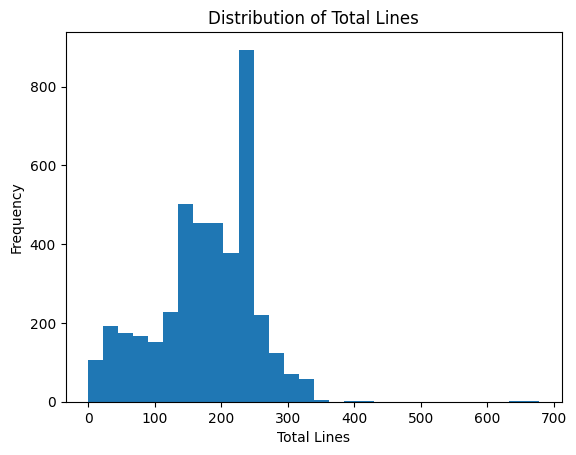

In [131]:
df["Total Lines"].plot(kind="hist", bins=30)
plt.title("Distribution of Total Lines")
plt.xlabel("Total Lines")
plt.ylabel("Frequency")
plt.show()

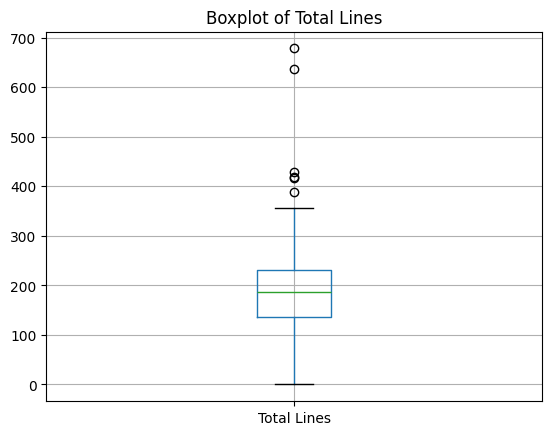

In [132]:
df.boxplot(column="Total Lines")
plt.title("Boxplot of Total Lines")
plt.show()

In [133]:
df["Total Lines"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25    137.00
0.50    186.00
0.75    232.00
0.90    254.00
0.95    277.00
0.99    325.34
Name: Total Lines, dtype: float64

In [134]:
df[df["Total Lines"].isna()][["Year", "Round", "Player", "Won?", "Final Score", "Total Lines", "Topout Type"]]

,Year,Round,Player,Won?,Final Score,Total Lines,Topout Type
114,2014,Top 16,Cameron Eure,Yes,642660,NaN,Natural
116,2014,Top 16,Cameron Eure,No,140600,NaN,Natural
118,2014,Top 16,Cameron Eure,No,468540,NaN,Natural
255,2016,Top 32,Adam Cornelius,No,51680,NaN,Natural
257,2016,Top 32,Adam Cornelius,No,298780,NaN,Natural
263,2016,Top 32,Vince,No,277630,NaN,Natural
265,2016,Top 32,Vince,No,82840,NaN,Natural
270,2016,Top 32,Chris Brady,No,428371,NaN,Natural
272,2016,Top 32,Chris Brady,No,35878,NaN,Natural
275,2016,Top 32,TheMetalBeast,No,265732,NaN,Natural


### Note on Total Lines

**What I found**  
- I found that `Total Lines` has 18 missing values.  
- The observed values range from 0 to 678, with most rows concentrated in a much narrower middle range.  
- The histogram and boxplot show some high-end outliers, but no especially useful standalone pattern from the univariate view.

**What I did not find**  
- I did not find a strong new insight from the raw univariate plots alone.  
- I also did not investigate yet why a few rows have `Total Lines = 0` or why the missing values occur in those specific matches.

**Working decision**  
- I will keep `Total Lines` as a core performance variable.  
- I will leave the 18 missing values as `NaN`.  
- I will not over-interpret the raw univariate plots and will analyze `Total Lines` later together with context variables such as `Year`, `Round`, and `Final Score`.

________________________________________________________________________________________________
________________________________________________________________________________________________

### End of the Univariate analysis

Overall, the univariate analysis showed that several structural columns in this dataset are strongly tied to tournament era and format. Because of that, some variables will be more meaningful in later grouped or comparative analysis than in standalone univariate plots.

________________________________________________________________________________________________
________________________________________________________________________________________________

# Bivariate EDA

In this section, I explore relationships between pairs of variables to understand how performance, playstyle, and tournament structure interact. The goal is to identify meaningful patterns, compare groups, and see which variables are most useful for explaining differences in scores, lines, and gameplay context.

### Structural and setup relationships
- Year × Round *(already checked in univariate)*
- Year × Playstyle *(already checked in univariate)*
- Year × Start Level *(already checked in univariate)*
- Year × SPS *(already checked in univariate)*
- Round × SPS *(already checked in univariate)*

### Performance by context
- Final Score × Year
- Final Score × Playstyle
- Final Score × Round
- Total Lines × Year
- Total Lines × Playstyle
- Total Lines × Round

### Performance relationships
- Final Score × Total Lines

Because many columns in this dataset are strongly tied to tournament era and format, I will interpret bivariate results carefully and avoid treating variables like Playstyle, Round, SPS, or Start Level as independent from Year.

________________________________________________________________________________________________
________________________________________________________________________________________________

In [136]:
df.groupby("Year")["Final Score"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2010,4.0,473569.0,114829.8,302118.0,463722.0,523812.0,533659.0,544534.0
2011,32.0,301114.0,185624.3,24845.0,107948.8,361589.0,431028.5,600271.0
2012,34.0,381519.1,207993.6,43394.0,165817.8,439706.5,558726.0,661525.0
2013,40.0,431044.5,158580.6,86444.0,402980.0,471690.0,525249.5,792471.0
2014,50.0,446120.8,163641.5,121220.0,335758.5,463820.0,584846.8,731651.0
2015,90.0,401544.2,179587.4,17860.0,280494.2,439821.5,528715.5,730190.0
2016,90.0,447940.4,185945.4,27360.0,345810.5,475635.5,560871.5,794768.0
2017,98.0,426313.0,209214.9,2.0,289169.0,454542.0,561180.0,933420.0
2018,174.0,454546.6,244825.6,3420.0,259747.0,466290.0,630665.8,934880.0


In [137]:
df.groupby("Year")["Final Score"].agg(["mean", "median", "min", "max"]).round(1)

,mean,median,min,max
Year,,,,
2010,473569.0,523812.0,302118,544534
2011,301114.0,361589.0,24845,600271
2012,381519.1,439706.5,43394,661525
2013,431044.5,471690.0,86444,792471
2014,446120.8,463820.0,121220,731651
2015,401544.2,439821.5,17860,730190
2016,447940.4,475635.5,27360,794768
2017,426313.0,454542.0,2,933420
2018,454546.6,466290.0,3420,934880


<Figure size 1200x600 with 0 Axes>

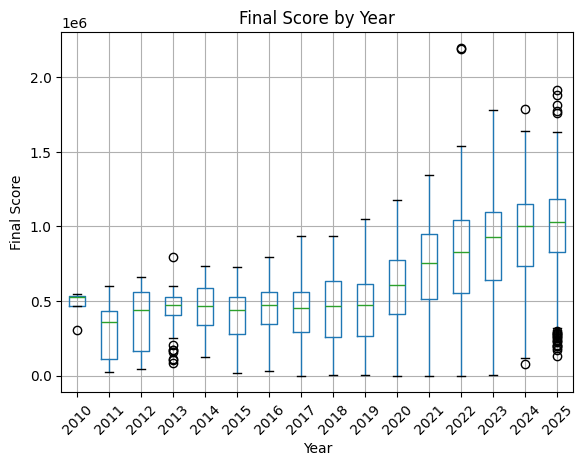

In [138]:
plt.figure(figsize=(12, 6))
df.boxplot(column="Final Score", by="Year")
plt.title("Final Score by Year")
plt.suptitle("")
plt.xlabel("Year")
plt.ylabel("Final Score")
plt.xticks(rotation=45)
plt.show()

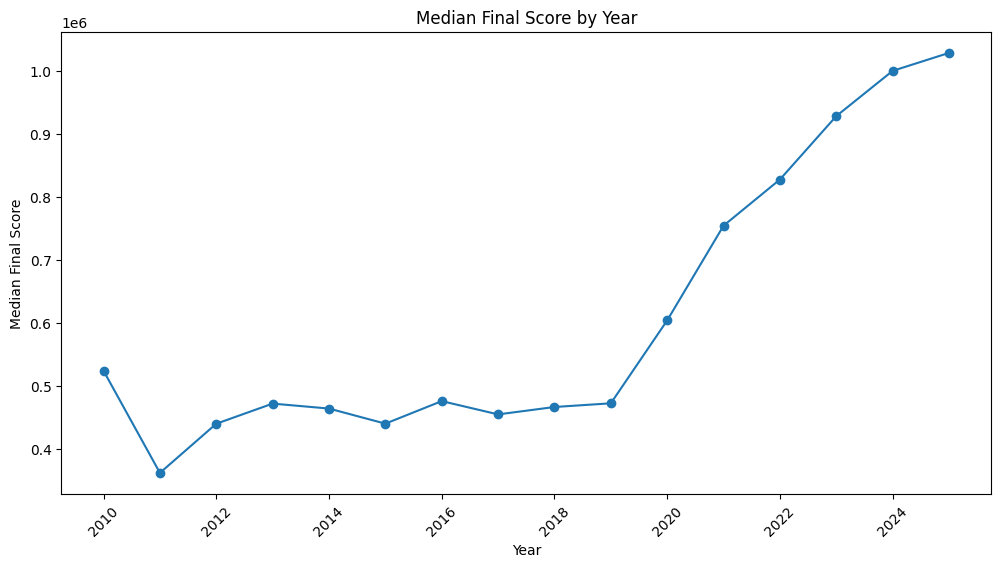

In [139]:
year_score = df.groupby("Year")["Final Score"].median()

plt.figure(figsize=(12, 6))
year_score.plot(marker="o")
plt.title("Median Final Score by Year")
plt.xlabel("Year")
plt.ylabel("Median Final Score")
plt.xticks(rotation=45)
plt.show()

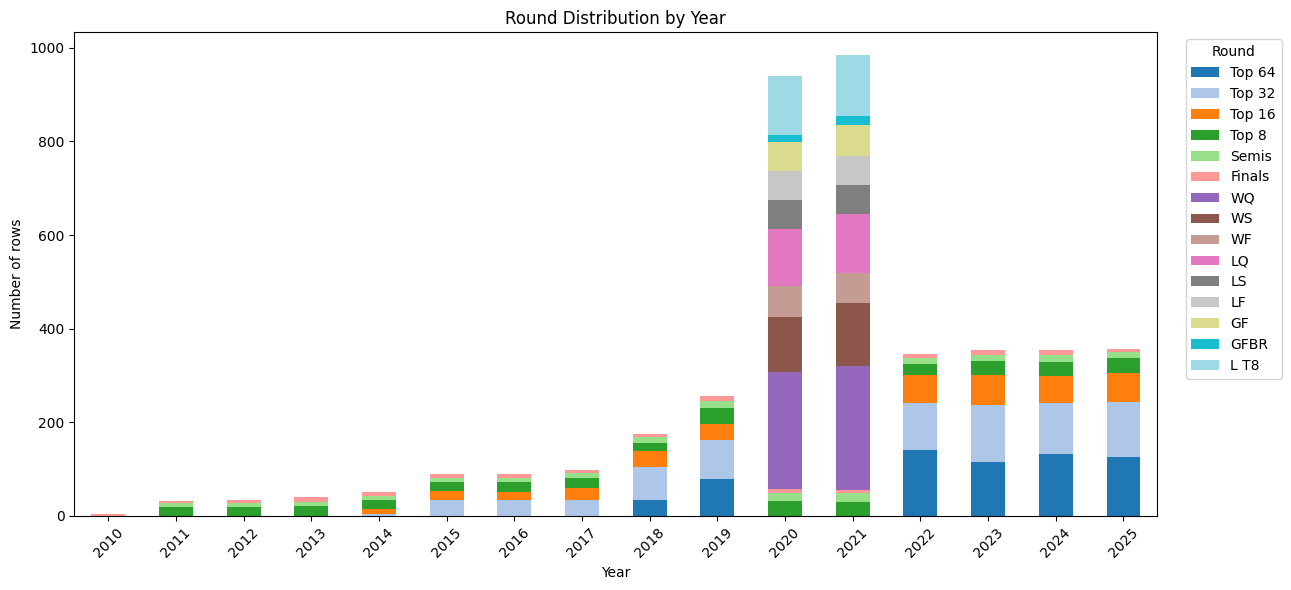

In [144]:

round_order = [
    "Top 64", "Top 32", "Top 16", "Top 8", "Semis", "Finals",
    "WQ", "WS", "WF", "LQ", "LS", "LF", "GF", "GFBR", "L T8"
]

round_by_year = pd.crosstab(df["Year"], df["Round"])

# only keep rounds that actually exist in the data, in your chosen order
round_order_present = [r for r in round_order if r in round_by_year.columns]
round_by_year = round_by_year[round_order_present]

cmap = plt.get_cmap("tab20")
colors = [cmap(i) for i in np.linspace(0, 1, len(round_order_present))]

round_by_year.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 6),
    color=colors
)

plt.title("Round Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Number of rows")
plt.xticks(rotation=45)
plt.legend(title="Round", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [141]:
df.groupby("Year")["Final Score"].count()

Year
2010      4
2011     32
2012     34
2013     40
2014     50
2015     90
2016     90
2017     98
2018    174
2019    256
2020    940
2021    984
2022    346
2023    354
2024    354
2025    356
Name: Final Score, dtype: int64

In [142]:
df[df["Year"] == 2010][["Player", "Round", "Final Score"]]

,Player,Round,Final Score
0,Jonas,Finals,530034
1,Harry Hong,Finals,302118
2,Jonas,Finals,544534
3,Harry Hong,Finals,517590


In [143]:
df[df["Year"] == 2011][["Player", "Round", "Final Score"]]

,Player,Round,Final Score
4,Jonas,Top 8,164153
5,Eli Markstrom,Top 8,117378
6,Jonas,Top 8,472503
7,Eli Markstrom,Top 8,350279
8,Robin Mihara,Top 8,43961
9,Ben Mullen,Top 8,30157
10,Robin Mihara,Top 8,431414
11,Ben Mullen,Top 8,430900
12,Harry Hong,Top 8,79661
13,Buco,Top 8,72643


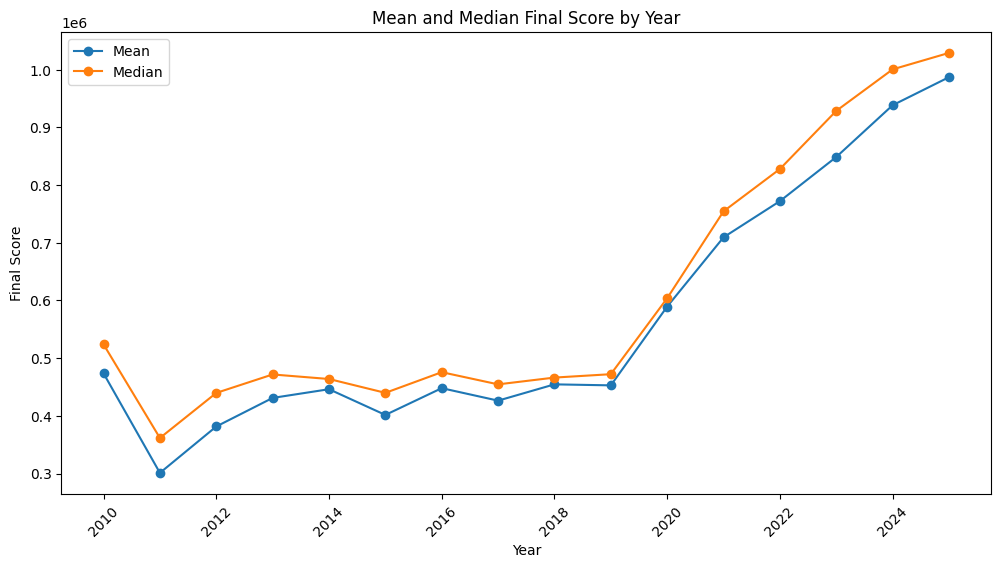

In [140]:
year_score_stats = df.groupby("Year")["Final Score"].agg(["mean", "median"]).round(1)

plt.figure(figsize=(12, 6))
plt.plot(year_score_stats.index, year_score_stats["mean"], marker="o", label="Mean")
plt.plot(year_score_stats.index, year_score_stats["median"], marker="o", label="Median")
plt.title("Mean and Median Final Score by Year")
plt.xlabel("Year")
plt.ylabel("Final Score")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [145]:
df.groupby(["Year", "Playstyle"])["Final Score"].median().unstack().round(1)

Playstyle,DAS,Roll,Tap
Year,,,
2010,523812.0,NaN,NaN
2011,361589.0,NaN,NaN
2012,439706.5,NaN,NaN
2013,471690.0,NaN,NaN
2014,463820.0,NaN,NaN
2015,439821.5,NaN,NaN
2016,471778.0,NaN,527019.0
2017,441244.0,NaN,552020.0
2018,451016.5,NaN,565610.0


In [146]:
df.groupby(["Year", "Playstyle"])["Final Score"].mean().unstack().round(1)

Playstyle,DAS,Roll,Tap
Year,,,
2010,473569.0,NaN,NaN
2011,301114.0,NaN,NaN
2012,381519.1,NaN,NaN
2013,431044.5,NaN,NaN
2014,446120.8,NaN,NaN
2015,401544.2,NaN,NaN
2016,438383.4,NaN,545900.1
2017,421485.6,NaN,579180.0
2018,437563.3,NaN,571885.5


In [147]:
df.groupby(["Year", "Playstyle"])["Final Score"].count().unstack(fill_value=0)

Playstyle,DAS,Roll,Tap
Year,,,
2010,4,0,0
2011,32,0,0
2012,34,0,0
2013,40,0,0
2014,50,0,0
2015,90,0,0
2016,82,0,8
2017,95,0,3
2018,152,0,22


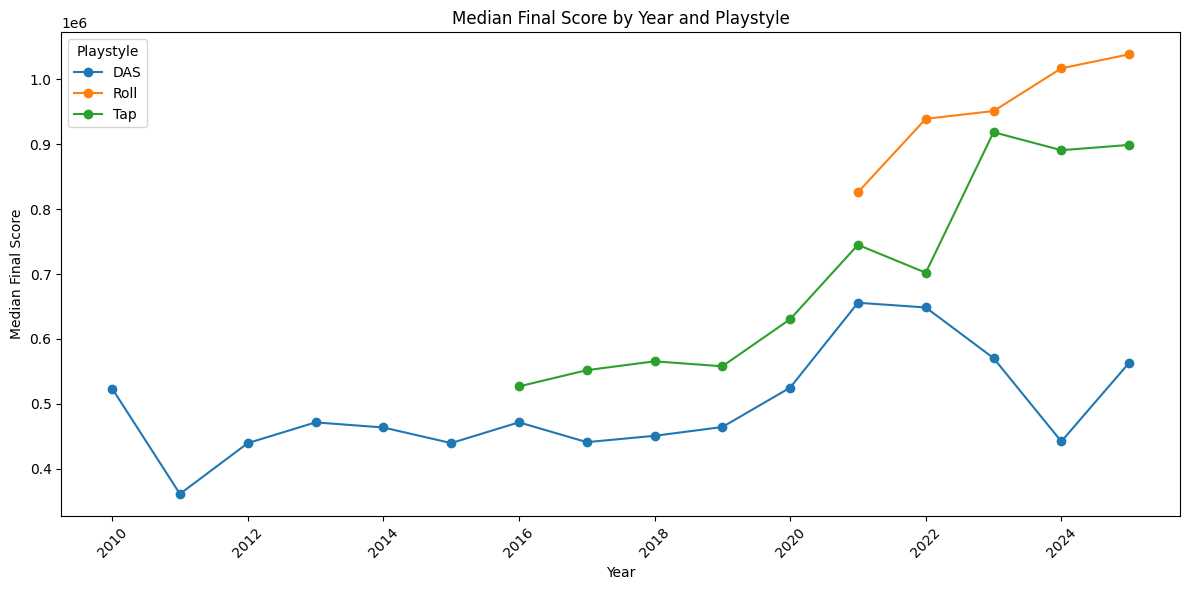

In [148]:
score_year_playstyle = df.groupby(["Year", "Playstyle"])["Final Score"].median().unstack()

score_year_playstyle.plot(marker="o", figsize=(12, 6))
plt.title("Median Final Score by Year and Playstyle")
plt.xlabel("Year")
plt.ylabel("Median Final Score")
plt.xticks(rotation=45)
plt.legend(title="Playstyle")
plt.tight_layout()
plt.show()

### Note on Final Score

**1. Final Score by Year**

**What I found**  
- I found that median and mean `Final Score` generally increase over time, with especially strong growth from 2020 onward.  
- However, this pattern is not directly interpretable as a pure improvement trend, because the dataset structure changes across years.  
- Early years contain fewer rows and narrower round coverage. For example, 2010 contains only 4 rows, all from `Finals`, which makes its median unusually unstable and not directly comparable to later years.  
- In 2011, the dataset already includes `Top 8`, `Semis`, and `Finals`, which helps explain why the median drops compared with 2010.  
- Later shifts in median score also appear to align with broader round coverage, such as `Top 32` entering the dataset in 2015 and `Top 64` entering in 2018 and 2019.  
- The pandemic-era years 2020 and 2021 are structurally unusual and should not be treated as fully comparable to the standard bracket years.  

**What I did not find**  
- I did not isolate the effect of tournament structure, round coverage, or playstyle in this step alone.  

**Working decision**  
- I will treat `Final Score × Year` as informative but strongly context-dependent.  
- I will avoid interpreting the score trend by year as a standalone explanation.  

---

**2. Final Score by Year and Round Distribution**

**What I found**  
- I found that changes in `Final Score` by year are partly shaped by changes in which rounds are included in the dataset.  
- The early years contain only later rounds, while later years include broader round coverage and therefore a wider player pool.  
- This means that year-to-year score comparisons are affected not only by gameplay changes, but also by who is included in the recorded matches.  
- For example, 2010 contains only `Finals`, while 2011 already includes `Top 8`, `Semis`, and `Finals`.  
- Later expansions such as `Top 32` and `Top 64` also affect the comparability of yearly score distributions.  

**What I did not find**  
- I did not build a dedicated `Final Score × Round` plot, because it would likely be too cluttered to read clearly in the notebook.  
- I also did not isolate the exact numerical effect of each round expansion on the score trend.  

**Working decision**  
- I will treat round distribution as an important part of interpreting `Final Score × Year`.  
- I will keep this as a manual structural interpretation rather than forcing a weak notebook plot.  
- If needed later, a cleaner visual may be better built in Tableau.  

---

**3. Final Score by Year and Playstyle**

**What I found**  
- I found that adding `Playstyle` makes the score trend much more informative.  
- `Tap` generally has higher median scores than `DAS`, and `Roll` generally has higher median scores than `Tap`.  
- This suggests that newer playstyles are strongly associated with higher final scores.  
- The count table also shows that some year-playstyle combinations are very small, especially in the transition years, so those points should be interpreted carefully.  

**What I did not find**  
- I did not isolate playstyle from all other factors that also change over time.  
- I therefore cannot say that playstyle alone causes the score increase.  

**Working decision**  
- I will treat playstyle as an important factor in explaining score growth over time.  
- I will not treat it as the only explanation, because year, format, and recording scope also change across the dataset.  
- A clearer grouped or interactive view may be better built later in Tableau if needed.

In [149]:
df.groupby("Year")["Total Lines"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2010,4.0,200.0,49.2,133.0,179.5,211.0,231.5,245.0
2011,32.0,102.2,61.5,6.0,42.2,116.0,141.2,191.0
2012,34.0,150.9,83.9,9.0,72.0,181.0,223.8,272.0
2013,40.0,152.8,57.7,27.0,134.2,163.0,189.5,251.0
2014,47.0,153.4,53.5,37.0,119.5,164.0,199.5,230.0
2015,90.0,139.3,59.6,6.0,119.2,148.0,173.2,232.0
2016,81.0,151.9,54.3,10.0,143.0,157.0,185.0,232.0
2017,98.0,139.9,61.9,0.0,103.8,144.0,191.0,232.0
2018,174.0,142.4,66.2,4.0,89.5,148.0,199.5,235.0


In [150]:
df.groupby("Year")["Total Lines"].agg(["mean", "median", "min", "max"]).round(1)

,mean,median,min,max
Year,,,,
2010,200.0,211.0,133.0,245.0
2011,102.2,116.0,6.0,191.0
2012,150.9,181.0,9.0,272.0
2013,152.8,163.0,27.0,251.0
2014,153.4,164.0,37.0,230.0
2015,139.3,148.0,6.0,232.0
2016,151.9,157.0,10.0,232.0
2017,139.9,144.0,0.0,232.0
2018,142.4,148.0,4.0,235.0


<Figure size 1200x600 with 0 Axes>

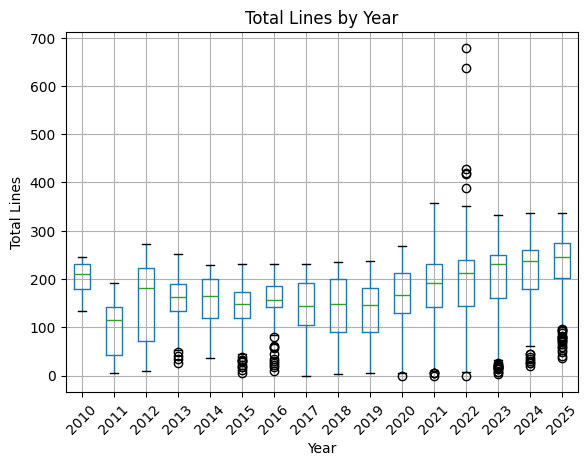

In [151]:
plt.figure(figsize=(12, 6))
df.boxplot(column="Total Lines", by="Year")
plt.title("Total Lines by Year")
plt.suptitle("")
plt.xlabel("Year")
plt.ylabel("Total Lines")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# outliers high

df[["Year", "Round", "Player", "Won?", "Final Score", "Total Lines", "Topout Type", "Playstyle"]].sort_values("Total Lines", ascending=False).head(20)

,Year,Round,Player,Won?,Final Score,Total Lines,Topout Type,Playstyle
3134,2022,Finals,EricICX,Yes,2194440,678.0,Intentional,Roll
3135,2022,Finals,Fractal,No,2189440,637.0,Natural,Roll
3130,2022,Finals,EricICX,No,1516660,428.0,Natural,Roll
3131,2022,Finals,Fractal,Yes,1539100,419.0,Natural,Roll
2988,2022,Top 32,EricICX,Yes,1524760,417.0,Natural,Roll
3132,2022,Finals,EricICX,Yes,1325560,388.0,Intentional,Roll
2751,2021,Top 8,Huffulufugus,Yes,1132640,357.0,Natural,Roll
3128,2022,Semis,EricICX,Yes,1272780,352.0,Intentional,Roll
3060,2022,Top 16,Xenophilius,No,1308320,345.0,Natural,Roll
2773,2021,Semis,Huffulufugus,Yes,1192140,345.0,Natural,Roll


In [ ]:
# outliers low

df[["Year", "Round", "Player", "Won?", "Final Score", "Total Lines", "Topout Type", "Playstyle"]].sort_values("Total Lines", ascending=True).head(20)

,Year,Round,Player,Won?,Final Score,Total Lines,Topout Type,Playstyle
361,2017,Top 32,Robin Mihara,No,2,0.0,Natural,DAS
3049,2022,Top 16,Tristop,No,0,0.0,Natural,Roll
2308,2021,WQ,Nevanator,No,0,0.0,Natural,Tap
1345,2020,WQ,B14NK,No,0,0.0,Natural,Tap
3159,2023,Top 64,Hana,No,3040,4.0,Natural,DAS
450,2018,Top 64,Greg V,No,3420,4.0,Natural,DAS
619,2019,Top 64,LouieSkouie,No,3907,5.0,Natural,DAS
1833,2021,WS,TegaMech,No,24700,6.0,Natural,Roll
19,2011,Top 8,Alex Kerr,No,24845,6.0,Natural,DAS
2543,2021,WQ,HarrieMcRacc,No,11400,6.0,Natural,Tap


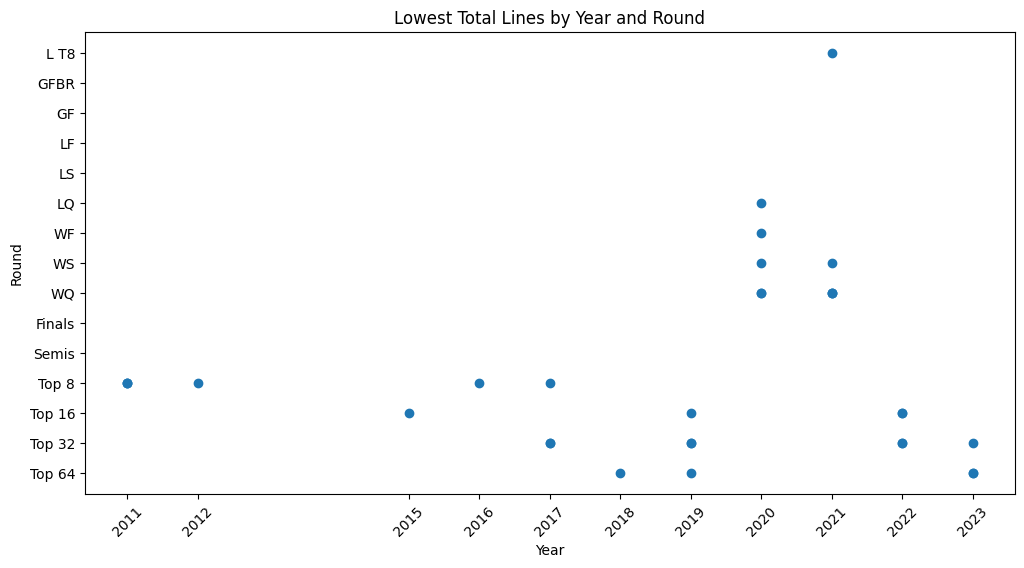

In [156]:
low_lines = df[df["Total Lines"] <= 10].copy()

round_order = [
    "Top 64", "Top 32", "Top 16", "Top 8", "Semis", "Finals",
    "WQ", "WS", "WF", "LQ", "LS", "LF", "GF", "GFBR", "L T8"
]

round_to_num = {r: i for i, r in enumerate(round_order)}
low_lines["Round_num"] = low_lines["Round"].map(round_to_num)

plt.figure(figsize=(12, 6))
plt.scatter(low_lines["Year"], low_lines["Round_num"])

plt.yticks(range(len(round_order)), round_order)
plt.title("Lowest Total Lines by Year and Round")
plt.xlabel("Year")
plt.ylabel("Round")
plt.xticks(sorted(low_lines["Year"].unique()), rotation=45)
plt.show()

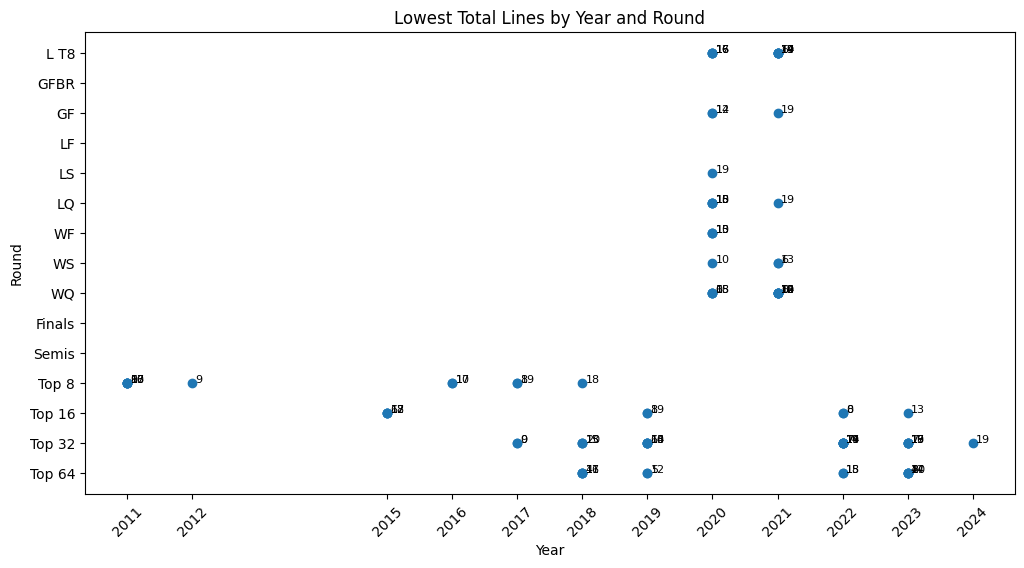

In [158]:
low_lines = df[df["Total Lines"] <= 20].copy()

round_order = [
    "Top 64", "Top 32", "Top 16", "Top 8", "Semis", "Finals",
    "WQ", "WS", "WF", "LQ", "LS", "LF", "GF", "GFBR", "L T8"
]

round_to_num = {r: i for i, r in enumerate(round_order)}
low_lines["Round_num"] = low_lines["Round"].map(round_to_num)

plt.figure(figsize=(12, 6))
plt.scatter(low_lines["Year"], low_lines["Round_num"])

for _, row in low_lines.iterrows():
    plt.text(
        row["Year"] + 0.05,
        row["Round_num"],
        str(int(row["Total Lines"])),
        fontsize=8
    )

plt.yticks(range(len(round_order)), round_order)
plt.title("Lowest Total Lines by Year and Round")
plt.xlabel("Year")
plt.ylabel("Round")
plt.xticks(sorted(low_lines["Year"].unique()), rotation=45)
plt.show()

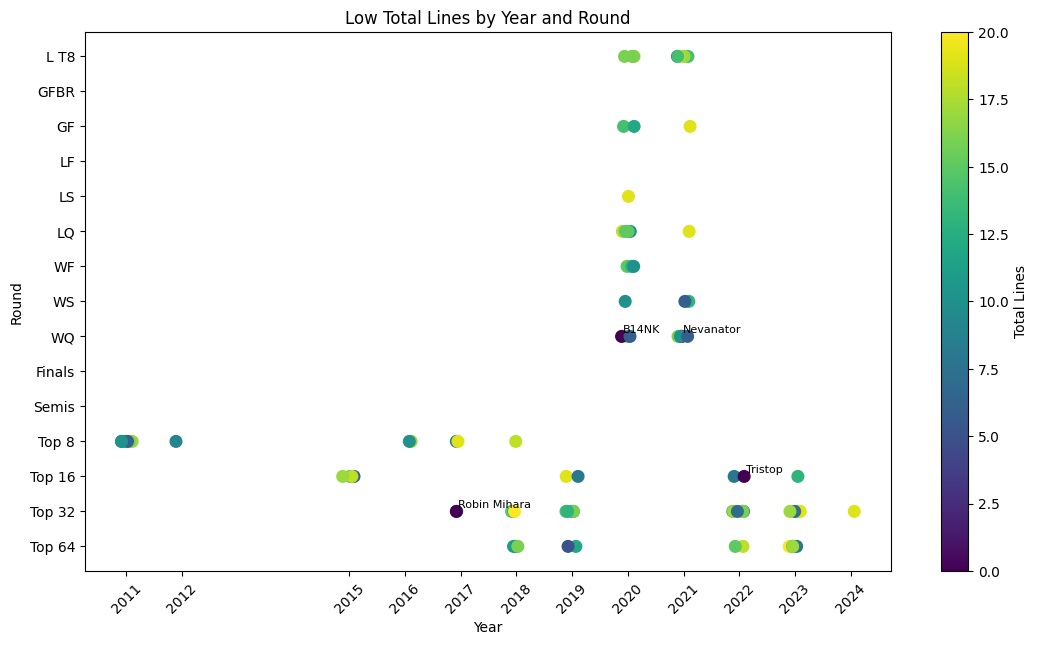

In [159]:
import numpy as np

low_lines = df[df["Total Lines"] <= 20].copy()

round_order = [
    "Top 64", "Top 32", "Top 16", "Top 8", "Semis", "Finals",
    "WQ", "WS", "WF", "LQ", "LS", "LF", "GF", "GFBR", "L T8"
]

round_to_num = {r: i for i, r in enumerate(round_order)}
low_lines["Round_num"] = low_lines["Round"].map(round_to_num)

np.random.seed(42)
low_lines["Year_jitter"] = low_lines["Year"] + np.random.uniform(-0.12, 0.12, size=len(low_lines))

plt.figure(figsize=(13, 7))
scatter = plt.scatter(
    low_lines["Year_jitter"],
    low_lines["Round_num"],
    c=low_lines["Total Lines"],
    s=70
)

plt.colorbar(scatter, label="Total Lines")
plt.yticks(range(len(round_order)), round_order)
plt.title("Low Total Lines by Year and Round")
plt.xlabel("Year")
plt.ylabel("Round")
plt.xticks(sorted(low_lines["Year"].unique()), rotation=45)

for _, row in low_lines[low_lines["Total Lines"] == 0].iterrows():
    plt.text(
        row["Year_jitter"] + 0.03,
        row["Round_num"] + 0.1,
        row["Player"],
        fontsize=8
    )

plt.show()

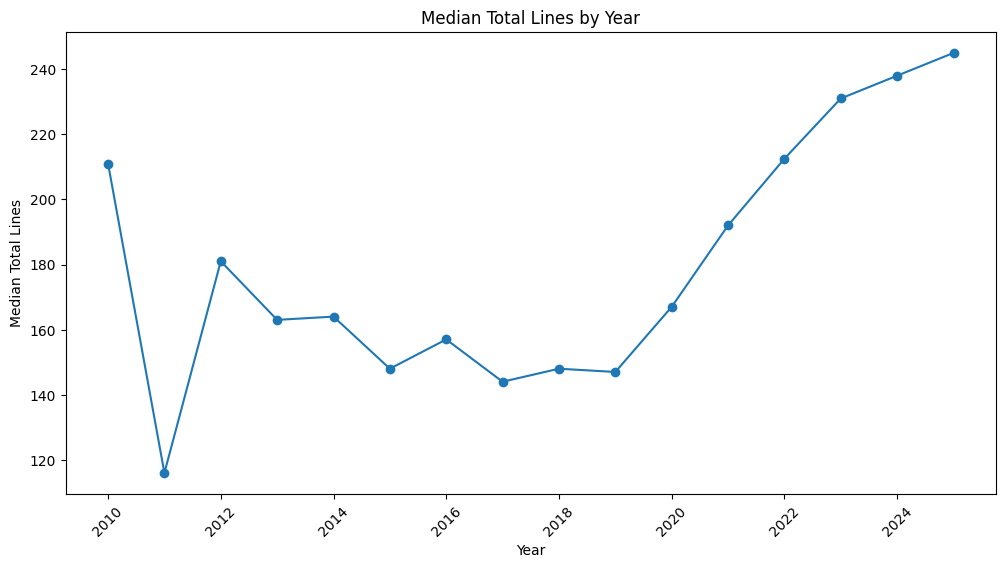

In [152]:
year_lines = df.groupby("Year")["Total Lines"].median()

plt.figure(figsize=(12, 6))
year_lines.plot(marker="o")
plt.title("Median Total Lines by Year")
plt.xlabel("Year")
plt.ylabel("Median Total Lines")
plt.xticks(rotation=45)
plt.show()

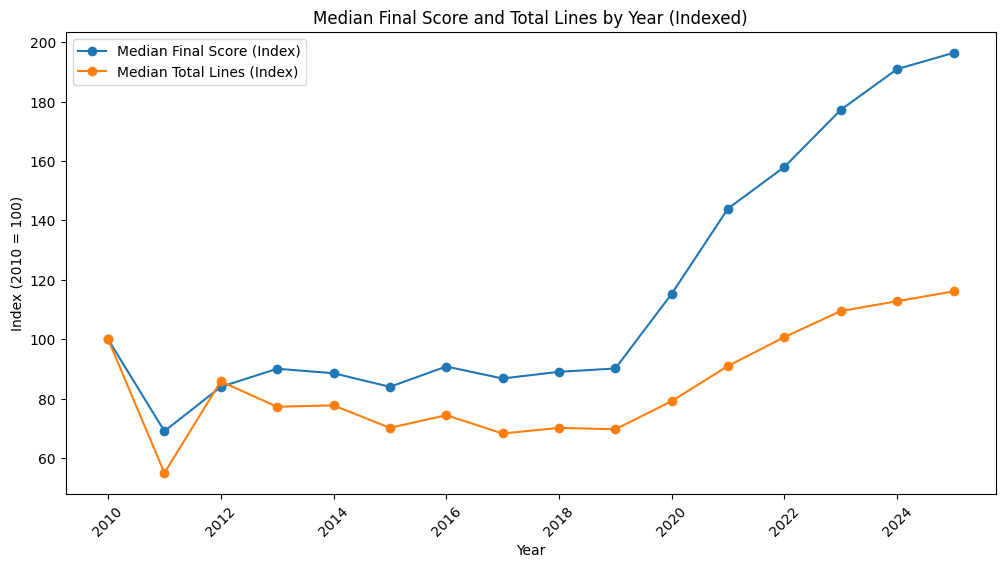

In [160]:
median_compare = df.groupby("Year")[["Final Score", "Total Lines"]].median().copy()

median_compare["Final Score Index"] = median_compare["Final Score"] / median_compare["Final Score"].iloc[0] * 100
median_compare["Total Lines Index"] = median_compare["Total Lines"] / median_compare["Total Lines"].iloc[0] * 100

plt.figure(figsize=(12, 6))
plt.plot(median_compare.index, median_compare["Final Score Index"], marker="o", label="Median Final Score (Index)")
plt.plot(median_compare.index, median_compare["Total Lines Index"], marker="o", label="Median Total Lines (Index)")
plt.title("Median Final Score and Total Lines by Year (Indexed)")
plt.xlabel("Year")
plt.ylabel("Index (2010 = 100)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

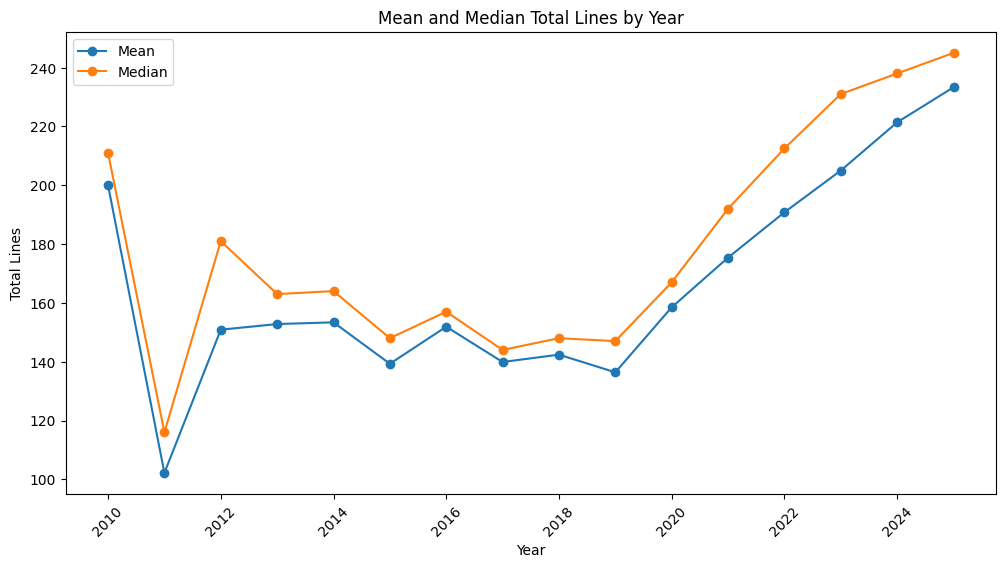

In [153]:
year_lines_stats = df.groupby("Year")["Total Lines"].agg(["mean", "median"]).round(1)

plt.figure(figsize=(12, 6))
plt.plot(year_lines_stats.index, year_lines_stats["mean"], marker="o", label="Mean")
plt.plot(year_lines_stats.index, year_lines_stats["median"], marker="o", label="Median")
plt.title("Mean and Median Total Lines by Year")
plt.xlabel("Year")
plt.ylabel("Total Lines")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [161]:
df.groupby(["Year", "Playstyle"])["Total Lines"].median().unstack().round(1)

Playstyle,DAS,Roll,Tap
Year,,,
2010,211.0,NaN,NaN
2011,116.0,NaN,NaN
2012,181.0,NaN,NaN
2013,163.0,NaN,NaN
2014,164.0,NaN,NaN
2015,148.0,NaN,NaN
2016,162.0,NaN,151.5
2017,143.0,NaN,165.0
2018,146.5,NaN,156.5


In [162]:
df.groupby(["Year", "Playstyle"])["Total Lines"].mean().unstack().round(1)

Playstyle,DAS,Roll,Tap
Year,,,
2010,200.0,NaN,NaN
2011,102.2,NaN,NaN
2012,150.9,NaN,NaN
2013,152.8,NaN,NaN
2014,153.4,NaN,NaN
2015,139.3,NaN,NaN
2016,151.4,NaN,156.5
2017,138.7,NaN,176.3
2018,140.5,NaN,155.8


In [163]:
df.groupby(["Year", "Playstyle"])["Total Lines"].count().unstack(fill_value=0)

Playstyle,DAS,Roll,Tap
Year,,,
2010,4,0,0
2011,32,0,0
2012,34,0,0
2013,40,0,0
2014,47,0,0
2015,90,0,0
2016,73,0,8
2017,95,0,3
2018,152,0,22


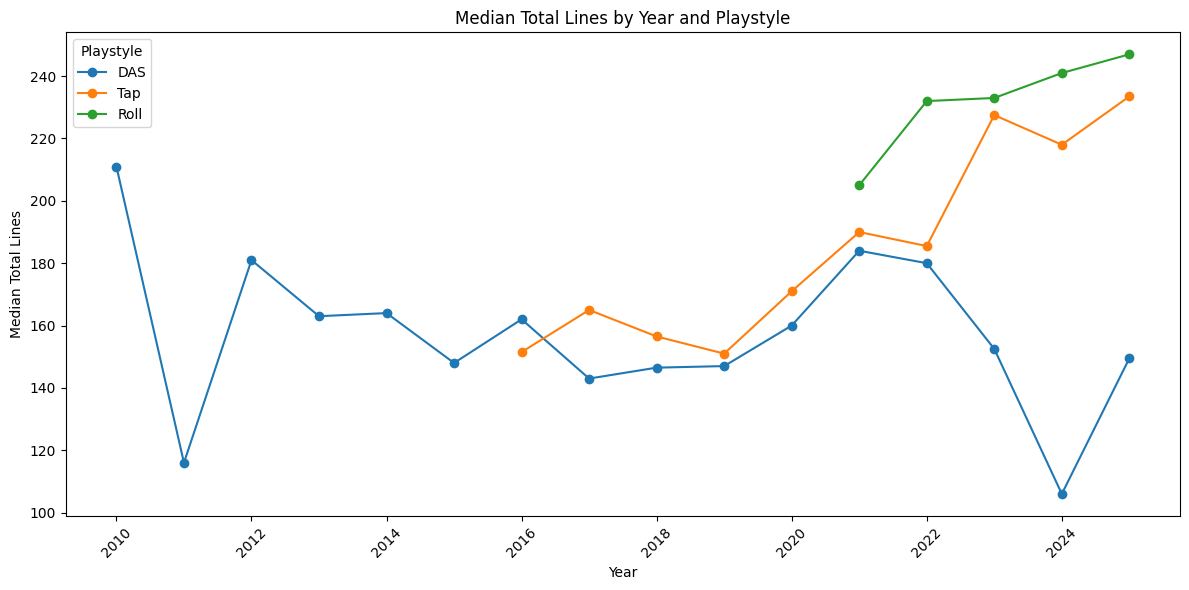

In [164]:

playstyle_order = ["DAS", "Tap", "Roll"]

lines_year_playstyle = df.groupby(["Year", "Playstyle"])["Total Lines"].median().unstack()
lines_year_playstyle = lines_year_playstyle[[p for p in playstyle_order if p in lines_year_playstyle.columns]]

lines_year_playstyle.plot(marker="o", figsize=(12, 6))
plt.title("Median Total Lines by Year and Playstyle")
plt.xlabel("Year")
plt.ylabel("Median Total Lines")
plt.xticks(rotation=45)
plt.legend(title="Playstyle")
plt.tight_layout()
plt.show()

In [165]:
df.groupby(["Year", "Playstyle"])["Total Lines"].count().unstack(fill_value=0).reindex(columns=["DAS", "Tap", "Roll"])

Playstyle,DAS,Tap,Roll
Year,,,
2010,4,0,0
2011,32,0,0
2012,34,0,0
2013,40,0,0
2014,47,0,0
2015,90,0,0
2016,73,8,0
2017,95,3,0
2018,152,22,0


### Note on Total Lines

**1. Total Lines by Year**

**What I found**  
- I found that median and mean `Total Lines` generally increase over time, especially from 2020 onward.  
- The overall pattern is broadly similar to what I saw for `Final Score`, with an early drop after 2010, a flatter middle period, and stronger growth in recent years.  
- The 2022 maximum is an especially large outlier and stands out clearly from the rest of the yearly distributions.  
- Mean and median do not look inconsistent with each other.

**What I did not find**  
- I did not find that `Total Lines × Year` alone gives a full explanation of performance change over time.  
- I also did not treat the yearly trend as directly comparable without considering changes in tournament structure and coverage.

**Working decision**  
- I will treat `Total Lines × Year` as informative but context-dependent.  
- I will interpret the yearly trend together with round coverage and playstyle.  

---

**2. Low and High Total Lines Outliers**

**What I found**  
- I found that the highest `Total Lines` outliers are extremely high, especially in 2022.  
- The highest outliers are all associated with `Roll`, which is an important pattern.  
- The lowest outliers include some rows with `Total Lines = 0`, and these are not just missing values.  
- Some very low `Total Lines` rows appear in surprisingly strong rounds such as `Top 8`, not only in earlier or weaker rounds.  
- When I tried to visualize the low outliers by year and round, the chart did not produce a very clear interpretive pattern.

**What I did not find**  
- I did not find a strong readable visual summary for the low outliers in the notebook.  
- I also did not yet explain why some very low `Total Lines` values occur in strong rounds.

**Working decision**  
- I will keep the outlier findings as an observation, especially that the highest outliers are all `Roll`.  
- I will not force a weak notebook visual for the low outliers.  
- If needed later, a clearer outlier view may be better built in Tableau.  

---

**3. Total Lines by Year and Playstyle**

**What I found**  
- I found that median `Total Lines` also tends to increase across playstyle eras.  
- `Tap` generally has higher median `Total Lines` than `DAS`, and `Roll` generally has higher median `Total Lines` than `Tap`.  
- This means newer playstyles are associated not only with higher scores, but also with longer survival.  
- However, the separation is less strong and less clean than what I saw for `Final Score`.  
- Some year-playstyle groups are small, so the later points, especially for `DAS`, should be interpreted carefully.

**What I did not find**  
- I did not isolate playstyle from all other changes happening across years.  
- I therefore cannot say that playstyle alone explains the increase in `Total Lines`.

**Working decision**  
- I will treat playstyle as an important factor in explaining `Total Lines` growth over time.  
- I will not treat it as the only explanation.  

---

**4. Small comparison with Final Score**

**What I found**  
- I found that median `Total Lines` and median `Final Score` follow a similar broad pattern over time.  
- Both show the major drop after 2010, a flatter middle period, and strong growth from around 2020 onward.  
- However, `Final Score` rises more steeply than `Total Lines` in the later years.

**What I did not find**  
- I did not investigate this relationship in depth yet.  
- I therefore treat this only as a first visual comparison, not as a full finding.

**Working decision**  
- I will treat this as a small preview only.  
- I will examine the relationship between `Final Score` and `Total Lines` more directly in the next step.

In [166]:
df[["Final Score", "Total Lines"]].corr()

,Final Score,Total Lines
Final Score,1.000000,0.937642
Total Lines,0.937642,1.000000


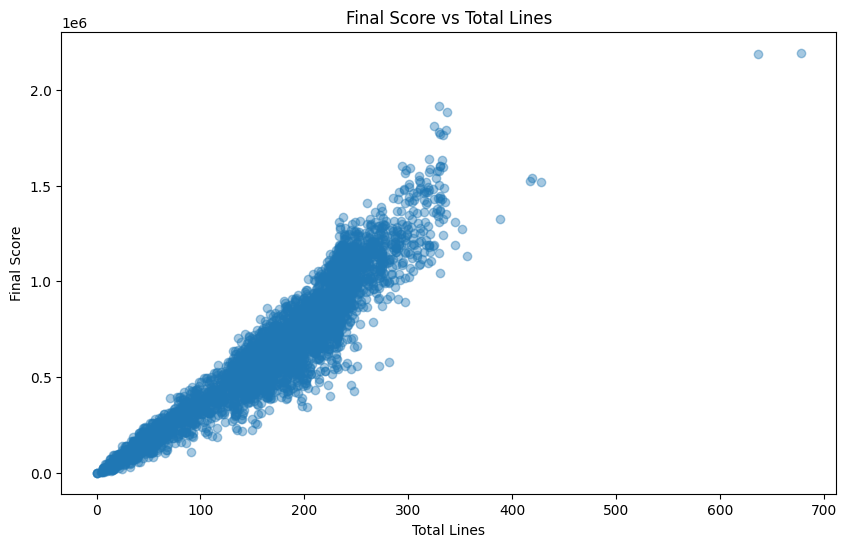

In [167]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Total Lines"], df["Final Score"], alpha=0.4)
plt.title("Final Score vs Total Lines")
plt.xlabel("Total Lines")
plt.ylabel("Final Score")
plt.show()

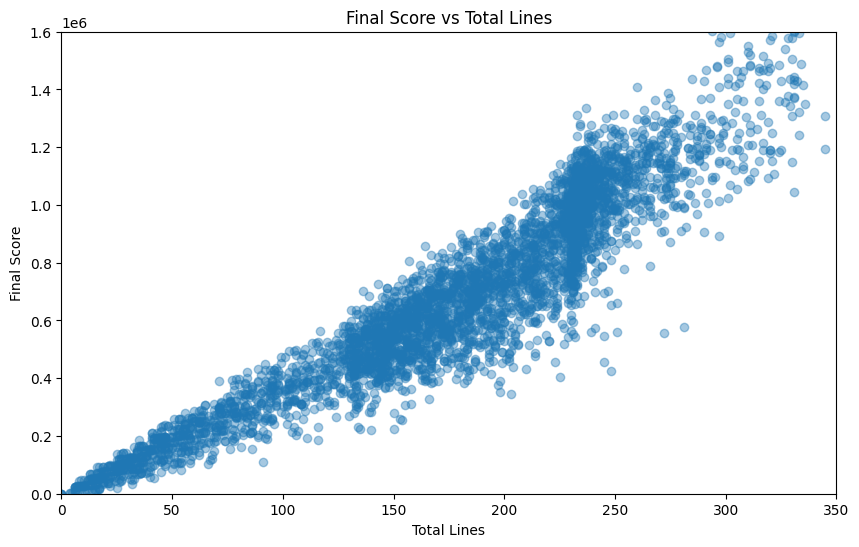

In [168]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Total Lines"], df["Final Score"], alpha=0.4)
plt.title("Final Score vs Total Lines")
plt.xlabel("Total Lines")
plt.ylabel("Final Score")
plt.xlim(0, 350)
plt.ylim(0, 1600000)
plt.show()

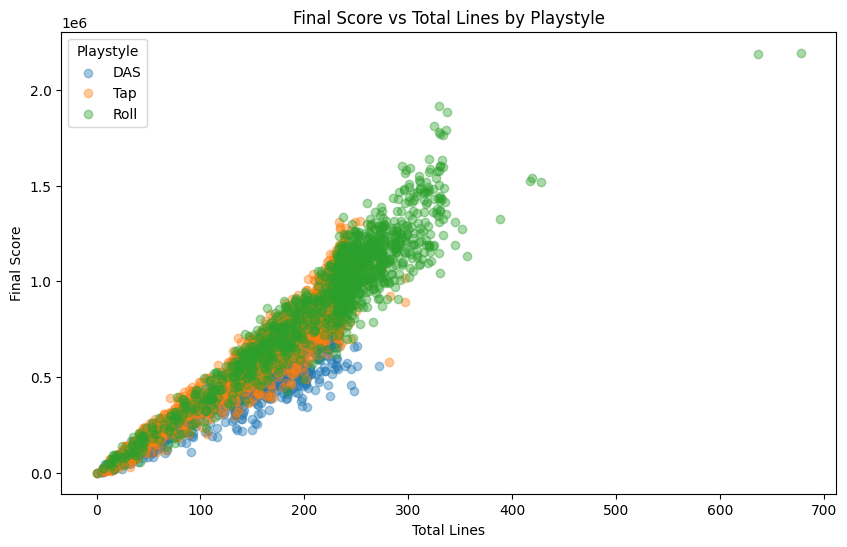

In [169]:
playstyle_order = ["DAS", "Tap", "Roll"]

plt.figure(figsize=(10, 6))

for playstyle in playstyle_order:
    subset = df[df["Playstyle"] == playstyle]
    plt.scatter(
        subset["Total Lines"],
        subset["Final Score"],
        alpha=0.4,
        label=playstyle
    )

plt.title("Final Score vs Total Lines by Playstyle")
plt.xlabel("Total Lines")
plt.ylabel("Final Score")
plt.legend(title="Playstyle")
plt.show()

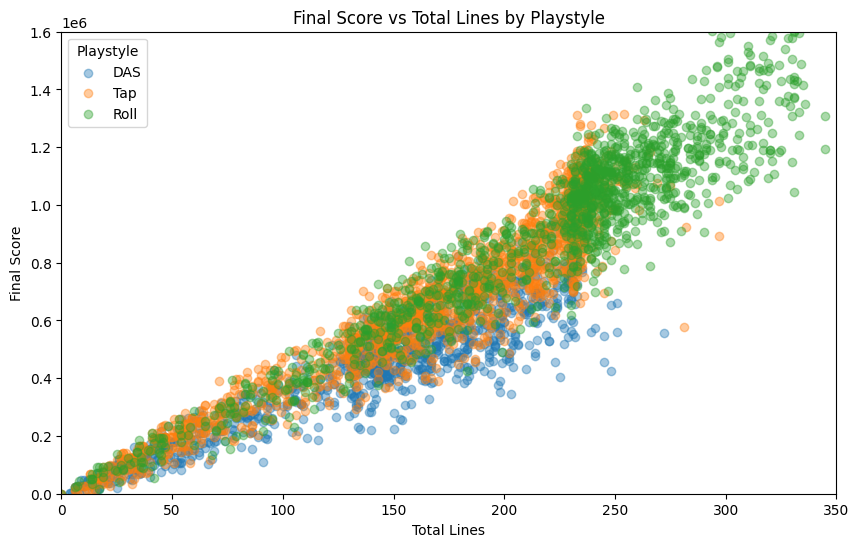

In [170]:
playstyle_order = ["DAS", "Tap", "Roll"]

plt.figure(figsize=(10, 6))

for playstyle in playstyle_order:
    subset = df[df["Playstyle"] == playstyle]
    plt.scatter(
        subset["Total Lines"],
        subset["Final Score"],
        alpha=0.4,
        label=playstyle
    )

plt.title("Final Score vs Total Lines by Playstyle")
plt.xlabel("Total Lines")
plt.ylabel("Final Score")
plt.xlim(0, 350)
plt.ylim(0, 1600000)
plt.legend(title="Playstyle")
plt.show()

### Note on Final Score and Total Lines

**What I found**  
- I found a very strong positive relationship between `Final Score` and `Total Lines`, with a correlation of 0.938.  
- The scatter plots show that players who survive more lines generally achieve higher final scores.  
- However, the relationship is not perfectly tight, especially at higher line counts where the spread in final scores becomes wider.  
- This means that `Total Lines` explains a large part of scoring, but not all of it.  
- When I added `Playstyle`, the point cloud shifted upward across playstyle eras: `DAS` tends to sit lowest, `Tap` above `DAS`, and `Roll` highest.  
- This suggests that newer playstyles are associated not only with more lines, but also with higher scores at similar line counts.  
- The highest score and line outliers are also dominated by `Roll`.

**What I did not find**  
- I did not prove that playstyle alone causes better scoring efficiency.  
- I also did not isolate the effects of year, format, or tournament structure from playstyle in this step.

**Working decision**  
- I will treat `Total Lines` as a major driver of `Final Score`.  
- I will also treat playstyle as an important factor in explaining why players with similar line counts can still end with different scores.  
- I will interpret this as strong descriptive evidence that later playstyles may be associated with more efficient scoring, while avoiding causal claims.